## Tarea 2 (2026) - Bastián Fierro Cabezas - 2021438823

# Respuestas

## Pregunta 1

- **Dataset inicial**. El dataset tiene 12040 filas (observaciones) y 41 variables. De las variables disponibles, tenemos que 

    - iso_code, date, CODE, NAME y country son strings y no posee valores faltantes.
    - retail_and_recreation_percent_change_from_baseline, grocery_and_pharmacy_percent_change_from_baseline, parks_percent_change_from_baseline, transit_stations_percent_change_from_baseline, workplaces_raw, residential_percent_change_from_baseline, trend, workplaces, Valor_Stringency_Index, Valor_GovernmentResponseIndex, Valor_EconomicSupportIndex, Valor_Containment_Health_index, workplace_closing y daily_cases, age_dependenc, old_age_dependency, young_age_dependency, sex_ratio, unemp, f_unemp, m_unemp, foreigners son números de coma flotante (float64) y no presentan datos faltantes.
 
Nota: Las estadisticas descriptivas del dataset original se encuentran en el bloque de desarrollo de código, también se incluye el número y porcentaje de datos faltantes por columna (en su mayoria cero). Dado que los datos resultantes no presentan más datos faltantes que afecten directamente al estudio, no es necesaria la imputación de datos.

- **Proceso de Limpieza**. Para poder llevar el dataset inicial a un dataset analítico y limpio se procedió de la siguiente forma:

    - Las variables d1, d2, d3, d4, d5 y d6 son variable snuméricas (int64) se desconoce su significado y además posee más del 50% de datos faltantes, caso similar con las variables edu2 y edu3, las cuales son números reales (float64). Se excluyen del estudio.
    - Se hace un estudio de distribuciones y outlier con boxplot para tener en cuenta la naturaleza de los datos. Se observan outliers leves en los extremos inferiores de `workplaces`, correspondientes a periodos de confinamiento estricto. **No se eliminan**: representan variación real del fenómeno.
    - Dada la magnitud y asimetría de la variable daily_cases, se decidión dejarla en escala logaritmica.
    - Verificamos la serie de tiempo por países de la movilidad laboral promedio por país para ver el comportamiento de los datos a lo largo del tiempo.
    - Se hace un análisis de Factor Inflación de Varianza (VIF) tanto pooled como within. Valor_Stringency_Index y retail_and_recreation_percent_change_from_baseline fueron las que tuvieron mayor VIF (cerca de 7), lo cual se considera que tienen alta correlación con otras covariables.
    - Se realizó una matriz de correlación tanto pooled como within, y se obtuvo que Valor_Stringency_Index y Valor_EconomicSupportIndex están fuertemente correlacionados, se elimina este último ya que no se considera un factor clave para el estudio. También las variables relacionadas a la movilidad (retail, transit y residential) tienen alta correlación entre si, sumado a alto VIF por parte de la variables transit y retail, las cuales se decidió eliminar por este motivo y porque son descritas implicitamente por la variable residential.

Finalmente, nos quedamos con un dataset de panel con 12,040 filas x 29 columnas perfectamente balanceado.

## Pregunta 2

El modelo básico de panel a utilizar es:

$$y_{it} = \theta T_t + \beta' X_{it} + \gamma' q_i + \mu_i + U_{it}$$

**Pooled OLS** asume $\text{Cov}(X_{it}, \mu_i) = 0$ y $E(U_{it}|\mu_i, X_{it}) = 0$, ignorando la heterogeneidad individual no observada. Es eficiente si esos supuestos se cumplen, pero puede producir estimadores sesgados si la unidad de análisis tiene características fijas no observadas correlacionadas con los regresores.

Las variables utilizadas para este modelo fueron:
Valor_Stringency_Index, log_cases, residential_percent_change_from_baseline, unemp, age_dependency, foreigners, industry y construction.

| Parameter | Std. Err. | T-stat | P-value | Lower CI | Upper CI |
|:---|---:|---:|---:|---:|---:|
| **const** | -3.7028 | 3.7726 | -0.9815 | 0.3264 | -11.098 | 3.6921 |
| **Valor_Stringency_Index** | -0.0556 | 0.0103 | -5.4250 | 0.0000 | -0.0757 | -0.0355 |
| **log_cases** | -0.0302 | 0.0341 | -0.8856 | 0.3758 | -0.0969 | 0.0366 |
| **residential_percent_change_from_baseline** | -1.4986 | 0.0280 | -53.484 | 0.0000 | -1.5535 | -1.4436 |
| **unemp** | -0.2200 | 0.0708 | -3.1052 | 0.0019 | -0.3588 | -0.0811 |
| **age_dependency** | 1.5821 | 5.8090 | 0.2723 | 0.7854 | -9.8045 | 12.969 |
| **foreigners** | -0.2203 | 0.1318 | -1.6716 | 0.0946 | -0.4787 | 0.0380 |
| **industry** | -5.5671 | 7.4211 | -0.7502 | 0.4532 | -20.114 | 8.9794 |
| **construction** | 26.526 | 33.682 | 0.7875 | 0.4310 | -39.497 | 92.549 |

**Interpretación – Pooled OLS:**

Para las variables significativas (considerando nivel de significancia $\alpha$=0.05),

- residential_percent_change_from_baseline (P-value: 0.0000): Es la variable más fuerte del modelo. Por cada 1 punto porcentual extra que la gente se queda en áreas residenciales, la movilidad fuera de casa cae en casi 1.5 unidades (-1.4986).

- Valor_Stringency_Index (P-value: 0.0000): Las políticas de restricción funcionan a nivel global. Por cada 1 punto que aumenta el índice de rigurosidad del gobierno, la movilidad analizada disminuye en -0.0556 unidades, manteniendo todo lo demás constante.

- unemp (Tasa de desempleo) (P-value: 0.0019): Las ciudades con mayor desempleo estructural presentan menor movilidad (cae -0.22 por cada punto de desempleo). esto sugiere que a mayor desempleo, menos viajes diarios al trabajo.


- El modelo logra explicar el 69.32% de la varianza total en la matriz de datos

**Limitación:** el Pooled OLS no controla por la heterogeneidad no observada $\mu_i$ (e.g., estructura económica local, cultura de teletrabajo), lo que puede sesgar los coeficientes si $\text{Cov}(X_{it}, \mu_i) \neq 0$.

## Pregunta 3

El estimador de efectos fijos (FE) elimina el componente individual no observado $\mu_i$ restando los promedios individuales (demeaning):

$$\tilde{y}_{it} = \beta'\tilde{X}_{it} + \tilde{U}_{it}, \quad \tilde{z}_{it} = z_{it} - \bar{z}_i$$

FE es consistente bajo el supuesto más débil de que $E(U_{it}|X_{it}, \mu_i) = 0$, permitiendo correlación arbitraria entre $X_{it}$ y $\mu_i$. Su desventaja es que no identifica variables fijas en el tiempo ($q_i$).

Las variables utilizadas para este modelo fueron:
Valor_Stringency_Index, log_cases, residential_percent_change_from_baseline. 

Las variables sociodemográficas (age_dependency, foreigners, industry, construction) no varían en el tiempo para cada ciudad, por lo que no pueden ser incluidas en un modelo de efectos fijos sin causar colinealidad perfecta. 
Por eso se excluyen en esta especificación. De incluirlas, habría multicolinealidad o desaparecerían automáticamente del modelo.

| Parameter | Std. Err. | T-stat | P-value | Lower CI | Upper CI |
|:---|---:|---:|---:|---:|---:|
| **const** | -7.1411 | 0.2780 | -25.688 | 0.0000 | -7.6860 | -6.5962 |
| **Valor_Stringency_Index** | 0.0034 | 0.0105 | 0.3215 | 0.7478 | -0.0172 | 0.0240 |
| **log_cases** | -0.1500 | 0.0248 | -6.0601 | 0.0000 | -0.1986 | -0.1015 |
| **residential_percent_change_from_baseline** | -1.5297 | 0.0231 | -66.112 | 0.0000 | -1.5750 | -1.4843 |

**Interpretación – Fixed Effects OLS:**

Al usar Efectos Fijos, cada ciudad se compara solo consigo misma a lo largo del tiempo, eliminando sesgos estructurales.

- Valor_Stringency_Index (No significativo): Las restricciones legales dictadas por el gobierno no reducen directamente la movilidad, siempre y cuando ya estemos controlando por el confinamiento residencial. Es decir, el decreto por sí solo no frena a la gente si no se traduce en que realmente se queden en casa.

- log_cases (Significativo y Negativo): Cuando los casos locales suben por encima de lo normal en una ciudad, la gente decide salir menos de forma voluntaria, independientemente del nivel de restricción oficial del gobierno.

- residential_percent_change_from_baseline (Significativo y Negativo): Es el mecanismo principal. Pasar más tiempo en casa reduce drásticamente la movilidad exterior.

- Las variables tiempo-invariantes (`Population`, `unemp`, `age_dependency`, etc.) son absorbidas por el efecto fijo y no son identificables.

$R^2$ Within (~0.70): Nos dice que el modelo logra explicar casi el 70% de las fluctuaciones de movilidad día a día al interior de cada ciudad.



## Pregunta 4

El modelo de Efectos Aleatorios (RE) asume $\text{Cov}(X_{it}, \mu_i) = 0$ y modela $\mu_i$ como un componente aleatorio con distribución propia. La transformación GLS aplica:

$$z^*_{it} = z_{it} - \lambda_i \bar{z}_i, \quad \lambda_i = 1 - \sqrt{\frac{\sigma^2_\mu}{T\sigma^2_\mu + \sigma^2_U}}$$

RE es **más eficiente** que FE si el supuesto de exogeneidad se cumple, y además **permite incluir variables de tiempo invariante** como las sociodemográficas.

Las variables utilizadas para este modelo fueron las mismas que en Pooled OLS:
Valor_Stringency_Index, log_cases, residential_percent_change_from_baseline, unemp, age_dependency, foreigners, industry y construction.

| Parameter | Std. Err. | T-stat | P-value | Lower CI | Upper CI |
|:---|---:|---:|---:|---:|---:|
| **const** | -0.6343 | 2.3377 | -0.2713 | 0.7861 | -5.2166 | 3.9481 |
| **Valor_Stringency_Index** | -0.0069 | 0.0047 | -1.4669 | 0.1424 | -0.0160 | 0.0023 |
| **log_cases** | -0.1306 | 0.0175 | -7.4766 | 0.0000 | -0.1648 | -0.0963 |
| **residential_percent_change_from_baseline** | -1.5212 | 0.0118 | -128.82 | 0.0000 | -1.5444 | -1.4981 |
| **unemp** | -0.2828 | 0.0408 | -6.9339 | 0.0000 | -0.3627 | -0.2028 |
| **age_dependency** | -1.5671 | 3.7908 | -0.4134 | 0.6793 | -8.9976 | 5.8634 |
| **foreigners** | -0.1810 | 0.0797 | -2.2710 | 0.0232 | -0.3373 | -0.0248 |
| **industry** | -6.3322 | 5.2146 | -1.2143 | 0.2246 | -16.554 | 3.8892 |
| **construction** | 5.5535 | 19.699 | 0.2819 | 0.7780 | -33.060 | 44.167 |

**Interpretación – Efectos Aleatorios:**

- $\theta$ ($\lambda$) = 0.7361. En Efectos Aleatorios, $\theta$ (theta) nos dice cuánto se parece este modelo a Efectos Fijos o a Pooled OLS. En nuestro caso, significa que el modelo de Efectos Aleatorios se está comportando en un 73.6% como Efectos Fijos y solo en un 26.4% como Pooled OLS.

- unemp (Significativo, P-value: 0.0000): Las ciudades con mayor desempleo estructural tienen sistemáticamente menor movilidad (-0.28).

- foreigners (Significativo, P-value: 0.0232): Ciudades con mayor tasa de población extranjera presentan una reducción marginal en su movilidad general (-0.18).

- industry, construction, age_dependency: No son significativos, por lo que se considera que no explican de buena forma los niveles de movilidad.

- Valor_Stringency_Index (No significativo, P=0.14): Al igual que en FE, el rigor de la política pública por sí solo no reduce la movilidad si ya estamos controlando por el factor de quedarse en casa.

- log_cases (Significativo, P=0.0000): El aumento de contagios locales deprime fuertemente la movilidad (-0.13), muy cerca del -0.15 de FE.

- R² (within) = 0.6965, y R² (between) = 0.6239 nos dicen que el modelo captura alrededor de un 69% de la variabilidad de los datos entre clases y un 62% de variabilidad explicada a traves del tiempo.

Nota: RE permite recuperar el efecto de variables sociodemográficas (`unemp`, `age_dependency`, `foreigners`) que son fijas en el tiempo y por tanto no identificables en FE.

## Pregunta 5

**¿Por qué existen diferencias entre los resultados?**

Las diferencias entre los tres modelos son consecuencia directa de distintos conjuntos de supuestos y distintas fuentes de variación utilizadas para la identificación:

| Aspecto | Pooled OLS | Fixed Effects | Random Effects |
|---|---|---|---|
| Variación usada | Between + Within | Solo Within | Between + Within (ponderado) |
| Controla $\mu_i$ | No | Sí (eliminado) | Parcialmente (modelado) |
| Variables time-invariant | Sí | No | Sí |
| Supuesto clave | $\text{Cov}(X,\mu)=0$ + obs. indep. | $E(U\|X,\mu)=0$ | $\text{Cov}(X,\mu)=0$ |
| Sesgo si $\text{Cov}(X,\mu)\neq 0$ | Sí | No | Sí |

**Resultado del Test de Hausman:**

$$\chi^2(3) = 1.5381, \quad p = 0.673510$$

**NO** se rechaza $H_0$ (que RE es consistente). Esto nos dice que las caracteristicas no observadas de cada ciudad NO están correlacionadas con las variables del modelo.

### ¿Cuál es el más adecuado?

**El modelo de Efectos aleatorios es el más adecuado** para responder la pregunta de investigación, por dos razones principales:

1. Evidencia Estadística (Test de Hausman): El p-valor obtenido de $0.6735$ indica que no existe evidencia estadística para rechazar la hipótesis nula ($H_0$). Esto confirma que los efectos individuales no observados de las ciudades no están correlacionados con tus variables explicativas. Bajo esta condición, RE es el estimador consistente y más eficiente (tiene menor varianza en sus errores que Efectos Fijos).

2. Riqueza Analítica: Para una investigación en políticas públicas, descartar las variables estructurales (como ocurre en FE) es una pérdida de información valiosa. RE permite responder a la pregunta de investigación con un panorama completo: demuestra los efectos dinámicos de la pandemia (log_cases) y al mismo tiempo confirma cómo vulnerabilidades sociodemográficas estáticas (unemp) deprimen la movilidad basal.

### ¿Qué variables son robustas a la especificación?

Las variables que mantienen **signo y significancia estadística en todos los modelos** son:

- residential_percent_change_from_baseline (Consistencia Absoluta): Es la variable más fuerte en los tres modelos ($p < 0.01$), manteniendo un coeficiente casi idéntico (alrededor de $-1.5$). Esto confirma que el canal principal para reducir la movilidad exterior es asegurar la permanencia en el hogar.

- log_cases (Robustez en Panel): Aunque falló en el modelo transversal (Pooled OLS), demostró ser extremadamente robusta en cuanto se controló la estructura de panel (FE y RE), manteniendo un efecto negativo y significativo cercano a $-0.13$ y $-0.15$.

- unemp (Robustez Estructural): En los dos modelos que matemáticamente permiten su evaluación (Pooled OLS y RE), la tasa de desempleo mantuvo un efecto negativo y altamente significativo ($p < 0.01$), confirmando que mercados laborales deprimidos generan menor movilidad intrínseca.

## Pregunta 6

El modelo CRE modela el componente no observado como:

$$\mu_i = \psi + \bar{X}_T \kappa + a_i, \quad E(a_i | X_{it}) = 0$$

Substituyendo en el modelo base:

$$y_{it} = \theta T_t + \beta' X_{it} + \gamma' q_i + \psi + \bar{X}_T \kappa + V_{it}$$

Los **promedios individuales** $\bar{X}_{iT}$ capturan la correlación entre $\mu_i$ y $X_{it}$, permitiendo recuperar estimadores consistentes vía GLS (como RE) manteniendo la posibilidad de incluir $q_i$. Si $\kappa = 0$, CRE colapsa a RE.

Para el estudio de este modelo se utilizaron las variables: Valor_Stringency_Index, log_cases,    residential_percent_change_from_baseline, mean_Valor_Stringency_Index, mean_log_cases, mean_residential_percent_change_from_baseline, unemp, age_dependency, foreigners, industry y construction.

Se obtuvieron los siguientes resultados:

| Parameter | Std. Err. | T-stat | P-value | Lower CI | Upper CI |
|:---|---:|---:|---:|---:|---:|
| **const** | -9.4729 | 7.4043 | -1.2794 | 0.2008 | -23.986 | 5.0407 |
| **Valor_Stringency_Index** | 0.0041 | 0.0049 | 0.8410 | 0.4003 | -0.0055 | 0.0137 |
| **log_cases** | -0.1526 | 0.0175 | -8.7186 | 0.0000 | -0.1869 | -0.1183 |
| **residential_percent_change_from_baseline** | -1.5286 | 0.0119 | -128.34 | 0.0000 | -1.5520 | -1.5053 |
| **mean_Valor_Stringency_Index** | -0.1008 | 0.0169 | -5.9768 | 0.0000 | -0.1339 | -0.0678 |
| **mean_log_cases** | 2.0502 | 1.4661 | 1.3984 | 0.1620 | -0.8236 | 4.9241 |
| **mean_residential_percent_change_from_baseline** | -1.4793 | 0.2392 | -6.1840 | 0.0000 | -1.9482 | -1.0104 |
| **unemp** | -0.1863 | 0.0522 | -3.5677 | 0.0004 | -0.2886 | -0.0839 |
| **age_dependency** | 5.3521 | 4.2401 | 1.2623 | 0.2069 | -2.9591 | 13.663 |
| **foreigners** | 0.2369 | 0.0921 | 2.5712 | 0.0101 | 0.0563 | 0.4175 |
| **industry** | -8.1301 | 5.2905 | -1.5367 | 0.1244 | -18.500 | 2.2402 |
| **construction** | 44.472 | 20.902 | 2.1276 | 0.0334 | 3.5008 | 85.443 |

Además, se aplicó un test de Mundlak, por lo que **2 de 3 coeficientes κ son significativos al 5%**, lo que confirma que $\mu_i$ está correlacionado con los regresores. CRE es preferible a RE puro.

**Interpretación – CRE:**

Los coeficientes del modelo constan de 2 clases, aquellos que captan el efecto dinámico (Corto plazo dentro de la ciudad):

- Casos Diarios (log_cases = -0.15): Por cada aumento porcentual en los contagios diarios locales, la movilidad cae inmediatamente.

- Índice de Rigurosidad (Valor_Stringency_Index = +0.004, No Significativo): Cambiar la ley hoy no cambia la movilidad mañana. El decreto en sí mismo, en el corto plazo, no es lo que frena a las personas (si controlamos por el tiempo que se quedan en casa).

- Permanencia Residencial (residential_percent_change_from_baseline = -1.52): Por cada punto extra que la gente se queda en casa, la movilidad exterior se desploma.

Por otro lado, los coeficientes captan los efectos estructurales (Largo Plazo / Diferencias entre ciudades):

- Promedio de Rigurosidad (mean_Valor_Stringency_Index = -0.10): Aunque la restricción diaria no importe, las ciudades que en promedio mantuvieron reglas más estrictas durante toda la pandemia lograron reducir su movilidad estructural base.

- Desempleo (unemp = -0.18): A mayor desempleo estructural, menor movilidad base en la ciudad.

- Población Extranjera (foreigners = +0.23) y Construcción (construction = +44.4): Las ciudades con mayor proporción de extranjeros o mayor industria de construcción tienen niveles de movilidad general más altos.

**¿Es adecuado dado la data?** Con 86 ciudades y 140 períodos, CRE es factible. Sin embargo, dado que los promedios $\bar{X}_{iT}$ se calculan sobre el período completo (que incluye tratamiento), pueden capturar efectos del tratamiento mismo, no solo heterogeneidad pre-existente. Para datos observacionales con intervenciones dinámicas como COVID, FE sigue siendo el estimador más robusto y transparente.


## Pregunta 7

**¿Qué modelo prefiere y por qué?**
El modelo preferido para esta investigación es el Modelo 4: Efectos Aleatorios Correlacionados (CRE / Enfoque de Mundlak).

Si bien el test de Hausman sugería RE, el resultado de Mundlak revisa esa conclusión: la significancia de los $\kappa$ indica que el supuesto de RE no se cumple en todas las variables. El test de Hausman puede tener baja potencia con solo 3 grados de libertad y covarianzas robustas/clusterizadas no estándar, por lo que el diagnóstico de Mundlak es más informativo aquí. CRE logró separar variables de política en dos dimensiones matemáticas.

Precisión Causal (Efecto Within): CRE estima los coeficientes dinámicos exactamente igual que el modelo de Efectos Fijos. Por lo tanto, está libre del sesgo de variables omitidas para explicar lo que ocurre día a día.

Riqueza Estructural (Efecto Between): A diferencia de Efectos Fijos (que borra todo lo que no cambia en el tiempo), CRE logra retener y validar el impacto de las variables sociodemográficas estructurales (como el desempleo o la población extranjera) y te permite medir el impacto "histórico" o promedio de las cuarentenas. Es, literalmente, el mejor de ambos mundos.

**¿Qué se puede inferir en general respecto del efecto de las restricciones gubernamentales sobre la movilidad laboral?**

A partir del modelo CRE y apoyándonos en los resultados la inferencia sobre el efecto de las restricciones sobre la movilidad (especialmente la laboral) tiene dos grandes conclusiones:

A. La Política Pública no es inmediato (Efecto de Corto Plazo). A nivel diario, los cambios o anuncios en el nivel de restricción (Valor_Stringency_Index) no logran reducir la movilidad de manera significativa por sí solos. Podemos inferir que la población no reacciona mecánicamente al decreto publicado hoy para no ir a trabajar mañana. Las verdaderas fuerzas que reducen la movilidad en el corto plazo son:

- El efecto miedo/riesgo: Las personas observan la ola de contagios en su ciudad (log_cases) y deciden auto-restringir sus salidas, independientemente de lo que diga la ley en ese momento.

- La permanencia residencial: El aislamiento efectivo (residential) es el verdadero mecanismo de transmisión. Si la política no logra que la gente se quede en casa de forma efectiva, la movilidad laboral no cae.

B. El "Efecto Ambiental" de la Política Normativa (Efecto de Largo Plazo). Aunque el decreto diario no frene a la gente, la media histórica de las restricciones (mean_Valor_Stringency_Index) demostró ser altamente significativa y negativa.
La inferencia central es que las restricciones gubernamentales funcionan fijando un ambiente normativo estructural. Los países/ciudades que, en promedio, mantuvieron regímenes más estrictos durante la pandemia, lograron asentar una cultura de adaptación residencial (como teletrabajo) y distanciamiento que deprimió sistemáticamente su movilidad laboral a lo largo de todo el período estudiado.

## Pregunta 8

### ¿Qué se hizo?

Se aplicó el método de **Control Sintético** para estimar el efecto causal del **segundo confinamiento nacional francés** (30 octubre 2020) sobre la movilidad laboral de París. La lógica es construir un *contrafactual* para París (qué habría ocurrido con su movilidad si no se hubiera impuesto el confinamiento) como combinación ponderada de otras ciudades que no recibieron exactamente el mismo tratamiento.

**Elección de ciudad y período de tratamiento:**

Se eligió **París** por ser la ciudad de mayor peso económico y poblacional de Francia y porque tiene una dinámica de movilidad claramente diferenciable por los confinamientos (vista en la serie de tiempo de la pregunta 1). El **segundo confinamiento** (semana 38, ~30 octbre 2020) se eligió como evento de tratamiento porque:
- Fue una intervención discreta y bien delimitada en el tiempo (4 semanas formales).
- Supuso un salto identificable en el Stringency Index de París (de ~45 a ~79 puntos).
- El período pre-tratamiento (semanas 1–37) incluye el primer confinamiento y la reapertura gradual, ofreciendo variación suficiente para calibrar el control sintético.

### Controles potenciales

Se usaron las **85 ciudades restantes del dataset** como donoras potenciales. Los predictores para construir el contrafactual fueron:

- **Time-invariant:** población, agricultura, industria, construcción, razón de dependencia etaria (total, joven y vieja), razón de sexo, desempleo total y femenino, proporción de extranjeros.
- **Especiales (promedio pre-tratamiento):** casos diarios, Stringency Index y cambio en actividad residencial.

### ¿A qué llegamos?

**Pesos del control sintético (PenalizedSynth):**

| Ciudad | Peso |
|---|---|
| **Barcelona** | 79.3% |
| **Milán** | 18.7% |
| **Berlín** | 1.9% |

**Pesos del Synth clásico (como verificación):**

| Ciudad | Peso |
|---|---|
| **Barcelona** | 59.3% |
| **Milán** | 36.2% |
| **Lens** | 4.5% |

Ambos métodos convergen en que **Barcelona y Milán** son las ciudades más similares a París en términos de movilidad laboral pre-tratamiento y características sociodemográficas —grandes centros metropolitanos de servicios con altas densidades y mercados laborales comparables. La consistencia entre ambos métodos refuerza la validez del contrafactual construido.

**Interpretación del Path Plot y Gaps Plot:**

- **Período pre-tratamiento (semanas 1–37):** el control sintético replica bien la trayectoria observada de movilidad laboral en París, validando la calidad del contrafactual. Ambas series capturan el primer confinamiento (semana ≈5) y la recuperación gradual posterior.

- **Período post-tratamiento (semanas 38–140):** se observa un **gap negativo** entre la movilidad real de París y el contrafactual sintético, interpretable como el **efecto causal adicional** del segundo confinamiento. Es decir, París tuvo menor movilidad laboral de la que hubiera tenido sin el confinamiento de octubre 2020.

- La persistencia del gap más allá del período formal de confinamiento sugiere **efectos de largo plazo**: adopción permanente de modalidades de teletrabajo, reorganización de los patrones de movilidad urbana y posiblemente cambios en las estructuras laborales que no se revertieron completamente al levantar las restricciones.

### Sesgo potencial en los modelos de panel y ventaja del control sintético

Los modelos de panel asumen una relación **lineal y estacionaria** entre restricciones y movilidad. Sin embargo, el fenómeno COVID es inherentemente dinámico: hay efectos de aprendizaje (las personas se adaptan con el tiempo), fatiga pandémica (menor cumplimiento en confinamientos sucesivos), anticipación de políticas (la movilidad cae antes del anuncio oficial) y cambios estructurales en el mercado laboral (adopción de teletrabajo). El control sintético no impone ninguna de estas restricciones funcionales: construye directamente el contrafactual para la unidad específica de interés, capturando la dinámica real del caso parisino. En este sentido, **el control sintético es complementario a los modelos de panel** y mitiga el sesgo dinámico que estos pueden introducir.

# Códigos

## Pregunta 1

**Enunciado:** Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. 

- Importación de librerías

In [165]:
# Librerías estándar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import missingno as msno
warnings.filterwarnings('ignore')

# Modelos de panel, control sintético y otras herramientas estadísticas
from linearmodels.panel import PooledOLS, PanelOLS, RandomEffects
from linearmodels.panel.model import BetweenOLS
from scipy import stats
import statsmodels.api as sm
from pysyncon import Dataprep, Synth, PenalizedSynth
import numpy.linalg as la
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Opciones de visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

- Carga de datos, exploración y limpieza inicial

In [166]:
# Cargar datos
df = pd.read_csv('../../../data/dataset_prueba.csv') #Pensado para usar desde 2026/Tarea 2
# df = pd.read_csv('dataset_prueba.csv') #Utilizar si se encuentra en la misma carpeta que el notebook

# Guardamos la forma original del dataset para referencia futura
og_shape = df.shape

# Preview de los datos
df.head()

print('=== Tipos de datos ===')
print(df.info())

# Eliminamos columnas de las cuales no tenemos información contextual ni definición por diccionario
cols_drop = ['d2', 'd3', 'd4', 'd5', 'd6', 'edu2', 'edu3']
df.drop(columns=cols_drop, inplace=True)

# Dado que date está en string, debemos pasarlo a datetime
df['date'] = pd.to_datetime(df['date'])


=== Tipos de datos ===
<class 'pandas.DataFrame'>
RangeIndex: 12040 entries, 0 to 12039
Data columns (total 41 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   iso_code                                            12040 non-null  str    
 1   date                                                12040 non-null  str    
 2   retail_and_recreation_percent_change_from_baseline  12040 non-null  float64
 3   grocery_and_pharmacy_percent_change_from_baseline   12040 non-null  float64
 4   parks_percent_change_from_baseline                  12040 non-null  float64
 5   transit_stations_percent_change_from_baseline       12040 non-null  float64
 6   workplaces_raw                                      12040 non-null  float64
 7   residential_percent_change_from_baseline            12040 non-null  float64
 8   trend                                               12040 non-nu

- Información adicional

In [167]:
print(f'Dimensiones del dataset original: {og_shape[0]:,} filas x {og_shape[1]} columnas')
print(f'Dimensiones del dataset con cambios: {df.shape[0]:,} filas x {df.shape[1]} columnas\n')
print(f'Período: {df["date"].min().date()} a {df["date"].max().date()}\n')
print(f'Ciudades únicas: {df["NAME"].nunique()}, {df["NAME"].unique()}\n') #Seleccionaremos una más adelante
print(f'Países: {list(df["iso_code"].str[:2].unique())}\n')

Dimensiones del dataset original: 12,040 filas x 41 columnas
Dimensiones del dataset con cambios: 12,040 filas x 34 columnas

Período: 2020-02-17 a 2022-10-17

Ciudades únicas: 86, <StringArray>
[              'Berlin',            'Stuttgart', 'Freiburg im Breisgau',
            'Karlsruhe',             'Mannheim',              'München',
             'Nürnberg',             'Augsburg',               'Bremen',
    'Frankfurt am Main',            'Wiesbaden',               'Kassel',
              'Hamburg',              'Rostock',             'Hannover',
         'Braunschweig',                 'Köln',                'Essen',
             'Dortmund',           'Düsseldorf',               'Bochum',
            'Bielefeld',                 'Bonn',      'Mönchengladbach',
             'Duisburg',        'Gelsenkirchen',              'Münster',
               'Aachen',              'Krefeld',           'Oberhausen',
            'Wuppertal',                 'Kiel',               'Lübeck',
  

- Datos Faltantes

=== Datos Faltantes ===
Empty DataFrame
Columns: [Faltantes, Porcentaje (%)]
Index: []
No hay valores faltantes en el dataset.


<Axes: >

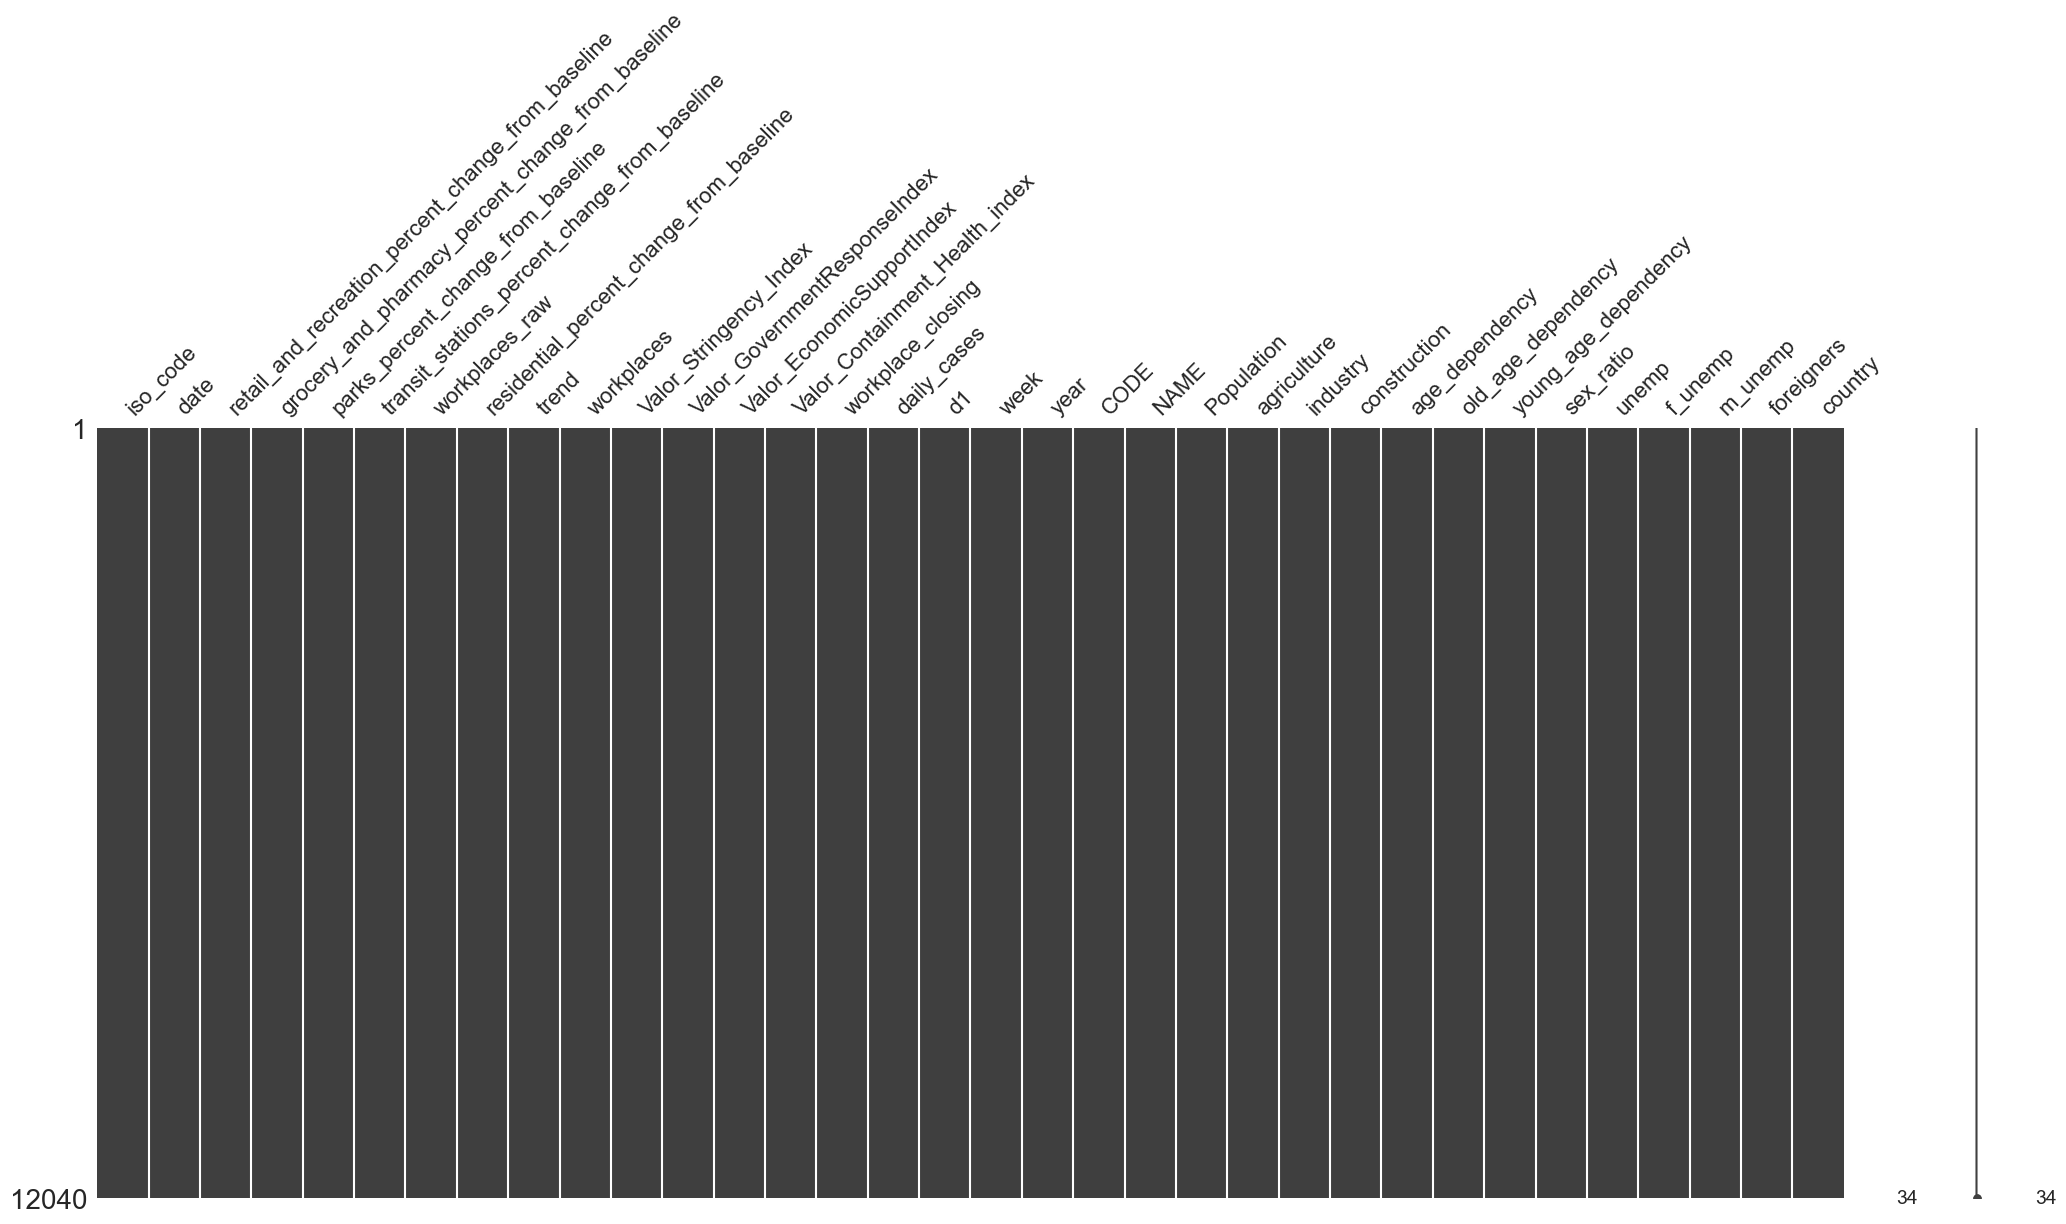

In [168]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Faltantes': missing, 'Porcentaje (%)': missing_pct})
print('=== Datos Faltantes ===')
print(missing_df[missing_df['Faltantes'] > 0].to_string())
if missing_df['Faltantes'].sum() == 0:
    print('No hay valores faltantes en el dataset.')

msno.matrix(df, )

- Distribuciones y outliers

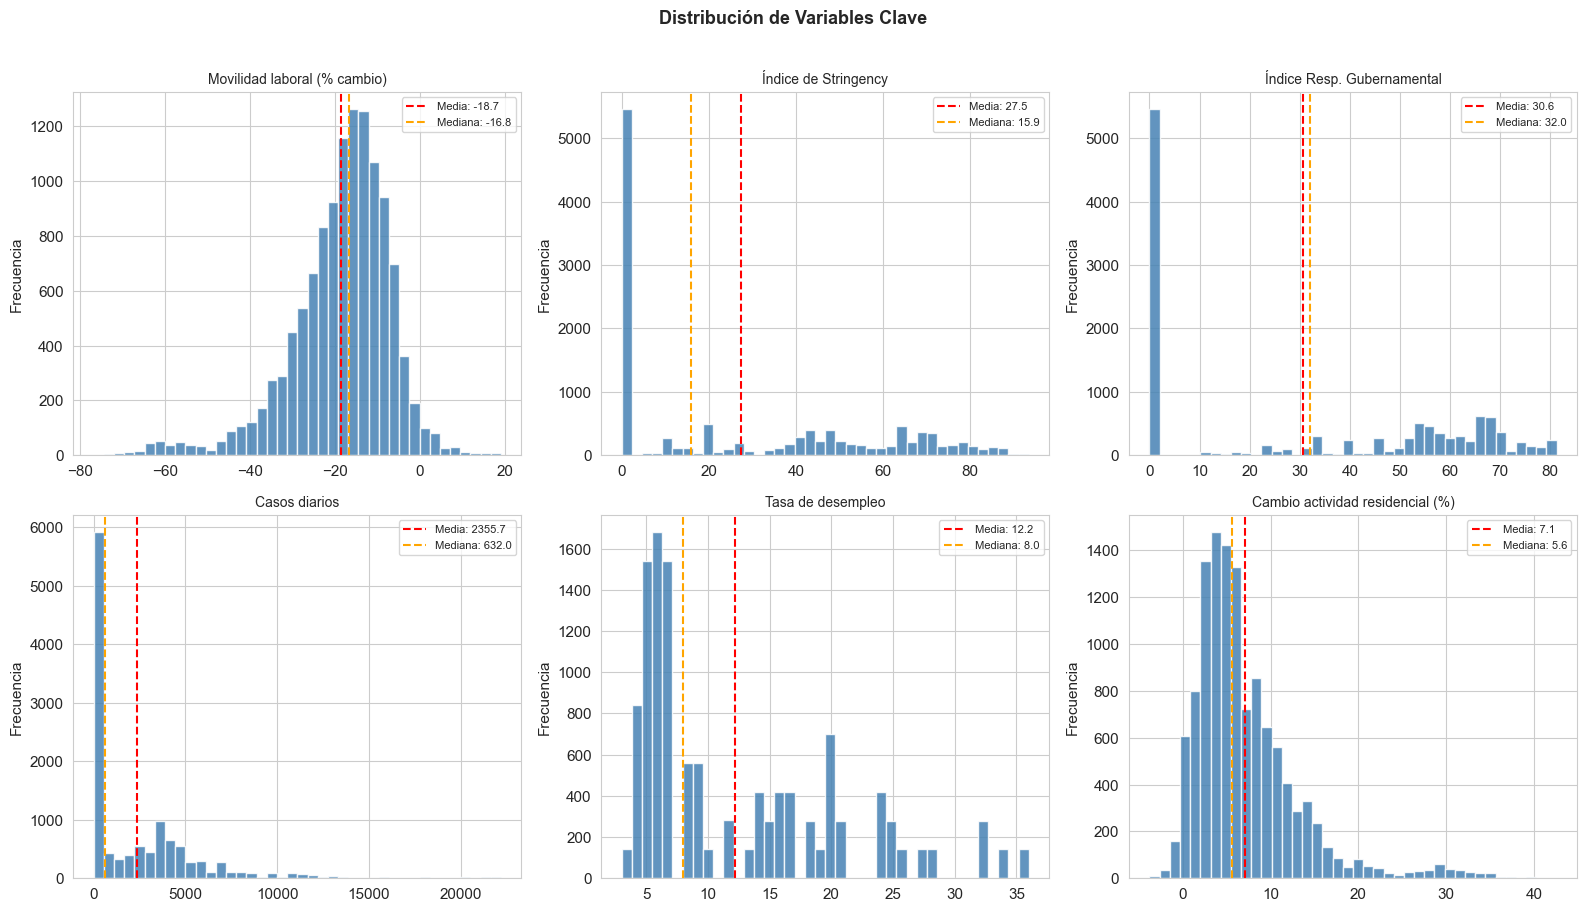

In [169]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

vars_plot = [
    ('workplaces',                'Movilidad laboral (% cambio)'),
    ('Valor_Stringency_Index',    'Índice de Stringency'),
    ('Valor_GovernmentResponseIndex', 'Índice Resp. Gubernamental'),
    ('daily_cases',               'Casos diarios'),
    ('unemp',                     'Tasa de desempleo'),
    ('residential_percent_change_from_baseline', 'Cambio actividad residencial (%)')
]

for ax, (var, label) in zip(axes, vars_plot):
    data = df[var].dropna()
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),  color='red',    ls='--', lw=1.5, label=f'Media: {data.mean():.1f}')
    ax.axvline(data.median(), color='orange', ls='--', lw=1.5, label=f'Mediana: {data.median():.1f}')
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_ylabel('Frecuencia')

plt.suptitle('Distribución de Variables Clave', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Observación: Casos diarios presenta una seria asimetría, por lo que se optará por utilizar una transformación logaritmica para esa variabel

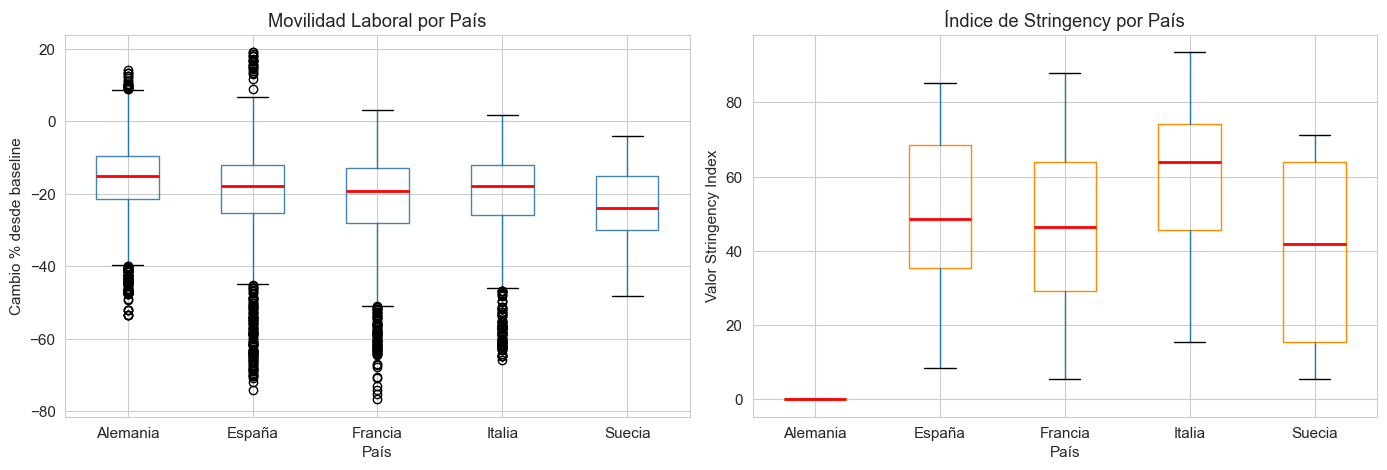

In [170]:
# Boxplots para detectar outliers por país
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

country_map = {'DE': 'Alemania', 'ES': 'España', 'FR': 'Francia', 'IT': 'Italia', 'SE': 'Suecia'}
df['country_name'] = df['iso_code'].str[:2].map(country_map)

df.boxplot(column='workplaces', by='country_name', ax=axes[0],
           boxprops=dict(color='steelblue'), medianprops=dict(color='red', lw=2))
axes[0].set_title('Movilidad Laboral por País')
axes[0].set_xlabel('País')
axes[0].set_ylabel('Cambio % desde baseline')

df.boxplot(column='Valor_Stringency_Index', by='country_name', ax=axes[1],
           boxprops=dict(color='darkorange'), medianprops=dict(color='red', lw=2))
axes[1].set_title('Índice de Stringency por País')
axes[1].set_xlabel('País')
axes[1].set_ylabel('Valor Stringency Index')

plt.suptitle('')
plt.tight_layout()
plt.show()

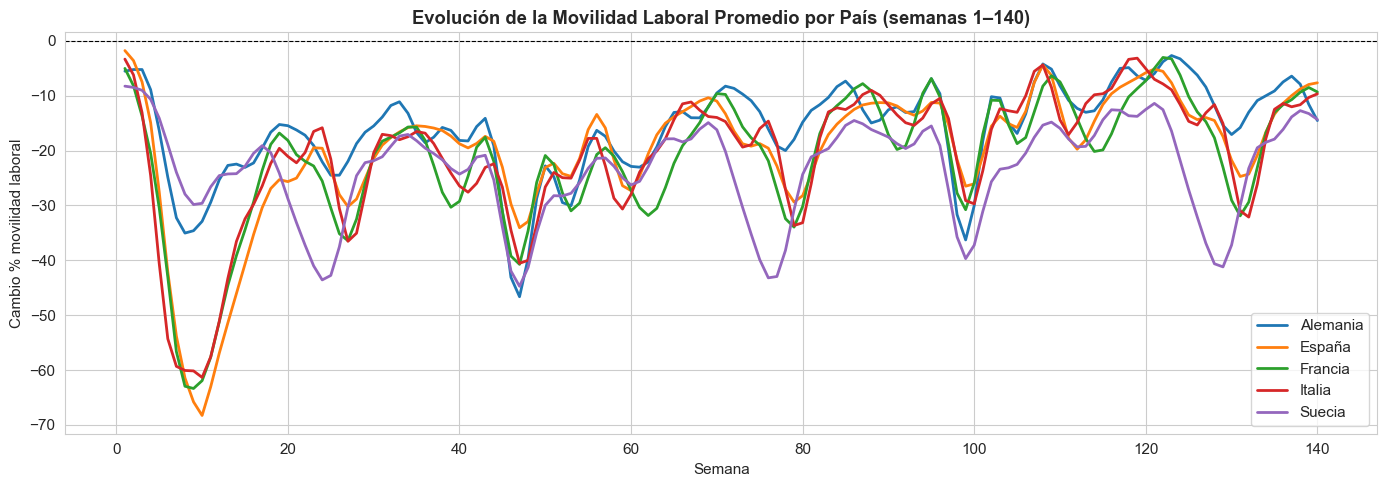

In [171]:
# Serie de tiempo: movilidad laboral promedio por país
fig, ax = plt.subplots(figsize=(14, 5))
colors = {'Alemania':'#1f77b4','España':'#ff7f0e','Francia':'#2ca02c','Italia':'#d62728','Suecia':'#9467bd'}

for country, grp in df.groupby('country_name'):
    ts = grp.groupby('week')['workplaces'].mean()
    ax.plot(ts.index, ts.values, label=country, lw=2, color=colors.get(country, 'grey'))

ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Semana')
ax.set_ylabel('Cambio % movilidad laboral')
ax.set_title('Evolución de la Movilidad Laboral Promedio por País (semanas 1–140)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Observaciones clave:**
- Hay caídas pronunciadas en movilidad laboral alrededor de las semanas 5–7 (primer confinamiento, marzo 2020) en todos los países.
- Suecia muestra una caída menos drástica, coherente con su estrategia de confinamiento suave.
- Se observan outliers leves en los extremos inferiores de `workplaces`, correspondientes a periodos de confinamiento estricto. **No se eliminan**: representan variación real del fenómeno.
- `daily_cases` tiene asimetría positiva marcada -> se tomará logaritmo al incluirla como control.

- Analisis de inflación de varianza y correlaciones

In [172]:
def calcular_vif(dataframe, variables):
    """
    Calcula el VIF para un subconjunto de variables de un DataFrame.
    Ignora las filas con NaNs en esas columnas específicas.
    """
    # Filtrar solo las variables de interés e intercepto
    X = dataframe[variables].dropna()
    
    # Es importante añadir una constante para que el VIF sea interpretable
    X['constante'] = 1 
    
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    
    # Retornar filtrando la constante
    return vif_data[vif_data["Variable"] != 'constante'].sort_values(by="VIF", ascending=False)

--- VIF Pooled ---
                                             Variable    VIF
0                              Valor_Stringency_Index 6.8630
1                          Valor_EconomicSupportIndex 5.5938
3   retail_and_recreation_percent_change_from_base... 5.1938
5            residential_percent_change_from_baseline 4.4682
4       transit_stations_percent_change_from_baseline 4.1129
6                                               unemp 2.9625
10                                       construction 2.7705
7                                      age_dependency 1.8993
8                                          foreigners 1.4495
2                                           log_cases 1.2469
9                                            industry 1.2438

--- VIF Within (Para Efectos Fijos) ---
                                             Variable    VIF
3   retail_and_recreation_percent_change_from_base... 6.6829
4       transit_stations_percent_change_from_baseline 5.9108
5            residential_

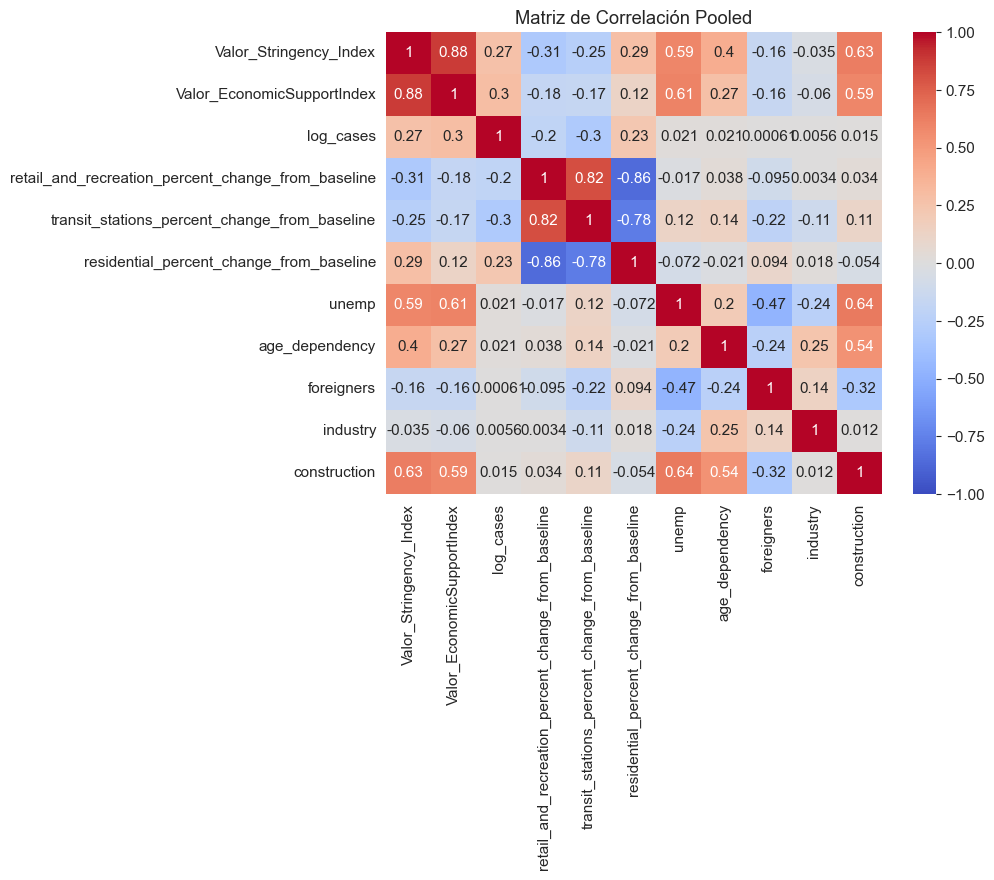

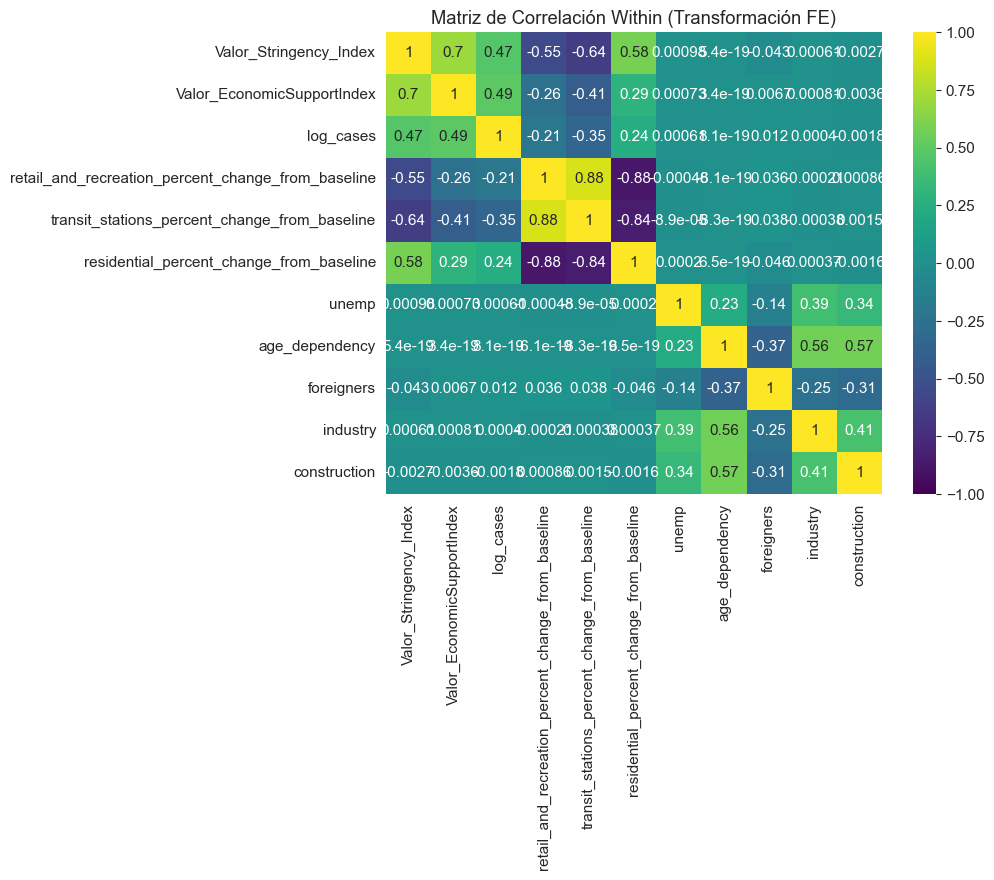

In [173]:
# Variable log de casos para reducir asimetría
df['log_cases'] = np.log1p(df['daily_cases'])

# Variables base:
regresores = [
    'Valor_Stringency_Index',
    'Valor_EconomicSupportIndex',
    'log_cases',
    'retail_and_recreation_percent_change_from_baseline',
    'transit_stations_percent_change_from_baseline',
    'residential_percent_change_from_baseline',
    'unemp',
    'age_dependency',
    'foreigners',
    'industry',
    'construction',
]

df_within = df.copy()
for col in regresores:
    df_within[col] = df_within[col] - df_within.groupby('iso_code')[col].transform('mean')
    
print("--- VIF Pooled ---")
print(calcular_vif(df, regresores))

print("\n--- VIF Within (Para Efectos Fijos) ---")
print(calcular_vif(df_within, regresores))

# 1. Correlación Pooled
plt.figure(figsize=(8, 6))
sns.heatmap(df[regresores].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación Pooled')
plt.show()

# 2. Correlación Within
# Restamos la media de cada ciudad a cada variable


plt.figure(figsize=(8, 6))
sns.heatmap(df_within[regresores].corr(), annot=True, cmap='viridis', vmin=-1, vmax=1)
plt.title('Matriz de Correlación Within (Transformación FE)')
plt.show()

In [174]:
df.drop(columns=['Valor_EconomicSupportIndex', 'retail_and_recreation_percent_change_from_baseline', 'transit_stations_percent_change_from_baseline'], inplace=True)
print("Eliminadas las columnas 'Valor_EconomicSupportIndex', 'retail_and_recreation_percent_change_from_baseline', 'transit_stations_percent_change_from_baseline' debido a alta colinealidad y altisima correlación")

Eliminadas las columnas 'Valor_EconomicSupportIndex', 'retail_and_recreation_percent_change_from_baseline', 'transit_stations_percent_change_from_baseline' debido a alta colinealidad y altisima correlación


- Preparación para panel

In [175]:
# Verificar balance del panel
panel_balance = df.groupby('NAME')['week'].count()
print('=== Balance del panel ===')
print(f'Observaciones por ciudad: min={panel_balance.min()}, max={panel_balance.max()}')
print(f'Panel balanceado: {panel_balance.nunique() == 1}')
print(f'Total ciudades: {df["NAME"].nunique()}')
print(f'Total periodos (semanas): {df["week"].nunique()}')

# Preparar índices de panel
df_panel = df.copy()
df_panel = df_panel.set_index(['NAME', 'week'])

print(f'Dimensiones del dataset de panel final: {df_panel.shape[0]:,} filas x {df_panel.shape[1]} columnas\n')
print('Panel configurado con índice (ciudad, semana).')

=== Balance del panel ===
Observaciones por ciudad: min=140, max=140
Panel balanceado: True
Total ciudades: 86
Total periodos (semanas): 140
Dimensiones del dataset de panel final: 12,040 filas x 31 columnas

Panel configurado con índice (ciudad, semana).


Observación: El panel está **perfectamente balanceado**: 86 ciudades × 140 semanas = 12 040 observaciones.

# Pregunta 2

**Enunciado:** Ejecute un modelo Pooled OLS para estimar la relacion entre las restricciones gubernamentales de movilidad y la variacion en movilidad laboral. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

El modelo básico de panel a utilizar es:

$$y_{it} = \theta T_t + \beta' X_{it} + \gamma' q_i + \mu_i + U_{it}$$

**Pooled OLS** asume $\text{Cov}(X_{it}, \mu_i) = 0$ y $E(U_{it}|\mu_i, X_{it}) = 0$, ignorando la heterogeneidad individual no observada. Es eficiente si esos supuestos se cumplen, pero puede producir estimadores sesgados si la unidad de análisis tiene características fijas no observadas correlacionadas con los regresores.

In [176]:
# Variables del modelo
y_var = 'workplaces'

# Variables independientes: restricciones + controles temporales y sociodemográficos
x_vars = [
    'Valor_Stringency_Index',
    'log_cases',
    'residential_percent_change_from_baseline',
    'unemp',
    'age_dependency',
    'foreigners',
    'industry',
    'construction',
]

In [177]:
# Preparar datos con constante
X_ols = df_panel[x_vars].copy()
X_ols = sm.add_constant(X_ols)
y_ols = df_panel[y_var]

# Pooled OLS con errores estándar robustos clusterizados por ciudad
model_pooled = PooledOLS(y_ols, X_ols)
res_pooled = model_pooled.fit(cov_type='clustered', cluster_entity=True)

print('=== Modelo 1: Pooled OLS (errores clusterizados por ciudad) ===')
print(res_pooled.summary.tables[1])

=== Modelo 1: Pooled OLS (errores clusterizados por ciudad) ===
                                            Parameter Estimates                                             
                                          Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------------------------
const                                       -3.7028     3.7726    -0.9815     0.3264     -11.098      3.6921
Valor_Stringency_Index                      -0.0556     0.0103    -5.4250     0.0000     -0.0757     -0.0355
log_cases                                   -0.0302     0.0341    -0.8856     0.3758     -0.0969      0.0366
residential_percent_change_from_baseline    -1.4986     0.0280    -53.484     0.0000     -1.5535     -1.4436
unemp                                       -0.2200     0.0708    -3.1052     0.0019     -0.3588     -0.0811
age_dependency                               1.5821     5.8090  

In [178]:
# Métricas

print(f"R² Within:  {res_pooled.rsquared_within:.4f}")
print(f"R² Overall: {res_pooled.rsquared_overall:.4f}")
print(f"R² Between: {res_pooled.rsquared_between:.4f}")
print(f'N observ.:    {int(res_pooled.nobs):,}')

R² Within:  0.6921
R² Overall: 0.6932
R² Between: 0.6995
N observ.:    12,040


- **Limitación:** el Pooled OLS no controla por la heterogeneidad no observada $\mu_i$ (e.g., estructura económica local, cultura de teletrabajo), lo que puede sesgar los coeficientes si $\text{Cov}(X_{it}, \mu_i) \neq 0$.

# Pregunta 3

**Enunciado:** Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

El estimador de efectos fijos (FE) elimina el componente individual no observado $\mu_i$ restando los promedios individuales (demeaning):

$$\tilde{y}_{it} = \beta'\tilde{X}_{it} + \tilde{U}_{it}, \quad \tilde{z}_{it} = z_{it} - \bar{z}_i$$

FE es consistente bajo el supuesto más débil de que $E(U_{it}|X_{it}, \mu_i) = 0$, permitiendo correlación arbitraria entre $X_{it}$ y $\mu_i$. Su desventaja es que no identifica variables fijas en el tiempo ($q_i$).

In [179]:
# Variables para FE (sin variables invariantes en el tiempo — no identificables)
x_vars_fe = [
    'Valor_Stringency_Index',
    'log_cases',
    'residential_percent_change_from_baseline',
]

#Nota: las variables sociodemográficas (age_dependency, foreigners, industry, construction) no varían en el tiempo para cada ciudad, 
# por lo que no pueden ser incluidas en un modelo de efectos fijos sin causar colinealidad perfecta. 
# Por eso se excluyen en esta especificación. De incluirlas, habría multicolinealidad o desaparecerían automáticamente del modelo.

In [180]:
X_fe = sm.add_constant(df_panel[x_vars_fe])
y_fe = df_panel[y_var]

# PanelOLS con efectos fijos de entidad (ciudad)
model_fe = PanelOLS(y_fe, X_fe, entity_effects=True, time_effects=False)
res_fe = model_fe.fit(cov_type='clustered', cluster_entity=True)

print('=== Modelo 2: Efectos Fijos (Within, con EE clusterizados) ===')
print(res_fe.summary.tables[1])

=== Modelo 2: Efectos Fijos (Within, con EE clusterizados) ===
                                            Parameter Estimates                                             
                                          Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------------------------
const                                       -7.1411     0.2780    -25.688     0.0000     -7.6860     -6.5962
Valor_Stringency_Index                       0.0034     0.0105     0.3215     0.7478     -0.0172      0.0240
log_cases                                   -0.1500     0.0248    -6.0601     0.0000     -0.1986     -0.1015
residential_percent_change_from_baseline    -1.5297     0.0231    -66.112     0.0000     -1.5750     -1.4843


In [181]:
# Métricas
print(f'R² (within):  {res_fe.rsquared_within:.4f}')
print(f'R² (between): {res_fe.rsquared_between:.4f}')
print(f'R² (overall): {res_fe.rsquared_overall:.4f}')

R² (within):  0.6968
R² (between): 0.3310
R² (overall): 0.6452


- FE controla por todas las características fijas no observadas de cada ciudad (e.g., densidad económica, cultura de trabajo presencial, infraestructura de transporte).
- El coeficiente de `Valor_Stringency_Index` en FE puede diferir del Pooled OLS: si ciudades con mayor nivel de restricciones crónicas también tienen estructuralmente menos movilidad (correlación positiva entre $\mu_i$ y $X_{it}$), Pooled OLS sobreestima el efecto.

- El R² within mide cuánta variación temporal (dentro de cada ciudad) explica el modelo.

# Pregunta 4

**Enunciado:** Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. 

El modelo de Efectos Aleatorios (RE) asume $\text{Cov}(X_{it}, \mu_i) = 0$ y modela $\mu_i$ como un componente aleatorio con distribución propia. La transformación GLS aplica:

$$z^*_{it} = z_{it} - \lambda_i \bar{z}_i, \quad \lambda_i = 1 - \sqrt{\frac{\sigma^2_\mu}{T\sigma^2_\mu + \sigma^2_U}}$$

RE es **más eficiente** que FE si el supuesto de exogeneidad se cumple, y además **permite incluir variables de tiempo invariante** como las sociodemográficas.

In [182]:
# RE puede incluir variables de tiempo invariante
x_vars_re = [
    'Valor_Stringency_Index',
    'log_cases',
    'residential_percent_change_from_baseline',
    'unemp',
    'age_dependency',
    'foreigners',
    'industry',
    'construction',
]

# Mismas variables que en Pooled OLS

In [183]:
X_re = sm.add_constant(df_panel[x_vars_re])
y_re = df_panel[y_var]

model_re = RandomEffects(y_re, X_re)
res_re = model_re.fit(cov_type='robust')

print('=== Modelo 3: Efectos Aleatorios (GLS, errores robustos) ===')
print(res_re.summary.tables[1])

=== Modelo 3: Efectos Aleatorios (GLS, errores robustos) ===
                                            Parameter Estimates                                             
                                          Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------------------------
const                                       -0.6343     2.3377    -0.2713     0.7861     -5.2166      3.9481
Valor_Stringency_Index                      -0.0069     0.0047    -1.4669     0.1424     -0.0160      0.0023
log_cases                                   -0.1306     0.0175    -7.4766     0.0000     -0.1648     -0.0963
residential_percent_change_from_baseline    -1.5212     0.0118    -128.82     0.0000     -1.5444     -1.4981
unemp                                       -0.2828     0.0408    -6.9339     0.0000     -0.3627     -0.2028
age_dependency                              -1.5671     3.7908    -

In [184]:
print(f'R² (within):  {res_re.rsquared_within:.4f}')
print(f'R² (between): {res_re.rsquared_between:.4f}')
print(f'R² (overall): {res_re.rsquared_overall:.4f}')
theta_val = float(np.mean(res_re.theta.values))
print(f'theta (lambda): {theta_val:.4f}')

R² (within):  0.6965
R² (between): 0.6239
R² (overall): 0.6863
theta (lambda): 0.7361


- RE permite recuperar el efecto de variables sociodemográficas (`unemp`, `age_dependency`, `foreigners`) que son fijas en el tiempo y por tanto no identificables en FE.
- El parámetro $\theta$ (lambda) indica cuánto pondera el modelo la variación between vs. within: $\theta \approx 1$ es equivalente a FE; $\theta \approx 0$ es equivalente a Pooled OLS.

Nota: La validez de RE depende críticamente del supuesto de no correlación entre $\mu_i$ y $X_{it}$, que evaluaremos con el test de Hausman.

# Pregunta 5

Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

- Funciones utiles para estudio

In [185]:
def extract_coefs(result, variables):
    params = result.params
    pvals  = result.pvalues
    stars  = lambda p: '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
    return {
        v: f"{params.get(v, float('nan')):.4f}{stars(pvals.get(v, 1))}"
        for v in variables
    }

# Tabla comparativa de coeficientes
vars_common = [
    'Valor_Stringency_Index',
    'log_cases',
    'residential_percent_change_from_baseline',
]


comp = pd.DataFrame({
    'Pooled OLS':  extract_coefs(res_pooled, vars_common),
    'Fixed FE':    extract_coefs(res_fe, vars_common),
    'Random RE':   extract_coefs(res_re, vars_common),
})

print('=== Tabla Comparativa de Coeficientes ===')
print('Nota: *** p<0.01, ** p<0.05, * p<0.1')
comp

=== Tabla Comparativa de Coeficientes ===
Nota: *** p<0.01, ** p<0.05, * p<0.1


,Pooled OLS,Fixed FE,Random RE
Valor_Stringency_Index,-0.0556***,0.0034,-0.0069
log_cases,-0.0302,-0.1500***,-0.1306***
residential_percent_change_from_baseline,-1.4986***,-1.5297***,-1.5212***


- Test de Hausman (FE vs RE)

In [186]:
# Test de Hausman (FE vs RE)
# H0: RE es consistente (Cov(X, mu) = 0)
# H1: FE es necesario (Cov(X, mu) ≠ 0)

coefs_fe = res_fe.params[vars_common]
coefs_re = res_re.params[vars_common]
diff     = coefs_fe - coefs_re

cov_fe = res_fe.cov.loc[vars_common, vars_common]
cov_re = res_re.cov.loc[vars_common, vars_common]
cov_diff = cov_fe - cov_re

try:
    cov_diff_inv = np.linalg.inv(cov_diff.values)
    hausman_stat = float(diff.values @ cov_diff_inv @ diff.values)
    hausman_pval = 1 - stats.chi2.cdf(hausman_stat, df=len(vars_common))
    print('=== Test de Hausman (FE vs RE) ===')
    print(f'  Estadístico χ²({len(vars_common)}): {hausman_stat:.4f}')
    print(f'  p-valor:                  {hausman_pval:.6f}')
    if hausman_pval < 0.05:
        print('  -> Se rechaza H0: usar Efectos FIJOS (RE es inconsistente).')
    else:
        print('  -> No se rechaza H0: Efectos Aleatorios son consistentes y eficientes.')
except np.linalg.LinAlgError:
    print('Matriz singular — usar criterio teórico para selección de modelo.')

=== Test de Hausman (FE vs RE) ===
  Estadístico χ²(3): 1.5381
  p-valor:                  0.673510
  -> No se rechaza H0: Efectos Aleatorios son consistentes y eficientes.


**Diferencias entre modelos:**
1. *Pooled OLS vs FE*: Pooled OLS no controla por la heterogeneidad no observada $\mu_i$. Si ciudades con estructuras económicas que predisponen mayor respuesta a restricciones también tienen niveles distintos de movilidad estructural, el coeficiente de Pooled OLS estará sesgado.
2. *FE vs RE*: FE explota solo la variación *within* (temporal dentro de cada ciudad) y es consistente incluso si $\text{Cov}(X_{it}, \mu_i) \neq 0$. RE es más eficiente si $\mu_i \perp X_{it}$, pero inconsistente si ese supuesto falla.
3. El test de Hausman evalúa formalmente si la diferencia FE−RE es sistemática.


# Pregunta 6

**Enunciado:** Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?

El modelo CRE modela el componente no observado como:

$$\mu_i = \psi + \bar{X}_T \kappa + a_i, \quad E(a_i | X_{it}) = 0$$

Substituyendo en el modelo base:

$$y_{it} = \theta T_t + \beta' X_{it} + \gamma' q_i + \psi + \bar{X}_T \kappa + V_{it}$$

Los **promedios individuales** $\bar{X}_{iT}$ capturan la correlación entre $\mu_i$ y $X_{it}$, permitiendo recuperar estimadores consistentes vía GLS (como RE) manteniendo la posibilidad de incluir $q_i$. Si $\kappa = 0$, CRE colapsa a RE.

In [187]:
# Variables time-varying para las que calculamos los promedios individuales
tv_vars = [
    'Valor_Stringency_Index',
    'log_cases',
    'residential_percent_change_from_baseline',
]

# Calcular promedios individuales (por ciudad)
df_work = df.copy()
means = df_work.groupby('NAME')[tv_vars].transform('mean')
mean_cols = {v: f'mean_{v}' for v in tv_vars}
means.rename(columns=mean_cols, inplace=True)

df_cre = pd.concat([df_work, means], axis=1)
df_cre = df_cre.set_index(['NAME', 'week'])

# Variables para CRE: originales + promedios + time-invariant
x_vars_cre = tv_vars + list(mean_cols.values()) + [
    'unemp', 'age_dependency', 'foreigners', 'industry', 'construction'
]

In [188]:
X_cre = sm.add_constant(df_cre[x_vars_cre])
y_cre = df_cre[y_var]

model_cre = RandomEffects(y_cre, X_cre)
res_cre = model_cre.fit(cov_type='robust')

print('=== Modelo 4: Efectos Aleatorios Correlacionados (CRE/Mundlak) ===')
print(res_cre.summary.tables[1])

=== Modelo 4: Efectos Aleatorios Correlacionados (CRE/Mundlak) ===
                                               Parameter Estimates                                               
                                               Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----------------------------------------------------------------------------------------------------------------
const                                            -9.4729     7.4043    -1.2794     0.2008     -23.986      5.0407
Valor_Stringency_Index                            0.0041     0.0049     0.8410     0.4003     -0.0055      0.0137
log_cases                                        -0.1526     0.0175    -8.7186     0.0000     -0.1869     -0.1183
residential_percent_change_from_baseline         -1.5286     0.0119    -128.34     0.0000     -1.5520     -1.5053
mean_Valor_Stringency_Index                      -0.1008     0.0169    -5.9768     0.0000     -0.1339     -0.0678
mean_log_cases       

In [189]:
# Test de Mundlak: ¿son los k (medias) conjuntamente significativos?
mean_coefs = res_cre.params[[c for c in res_cre.params.index if c.startswith('mean_')]]
mean_pvals = res_cre.pvalues[[c for c in res_cre.pvalues.index if c.startswith('mean_')]]

print('\n=== Test de Mundlak: coeficientes sobre los promedios individuales (k) ===')
print(pd.DataFrame({'Coeficiente': mean_coefs, 'p-valor': mean_pvals}).to_string())

sig_count = (mean_pvals < 0.05).sum()
print(f'\nSignificativos al 5%: {sig_count}/{len(mean_coefs)}')
if sig_count > 0:
    print('-> k ≠ 0: el componente no observado μ_i está correlacionado con los regresores. CRE prefiere a RE puro.')
else:
    print('-> k ≈ 0: CRE equivale a RE. El supuesto de no correlación es plausible.')


=== Test de Mundlak: coeficientes sobre los promedios individuales (k) ===
                                               Coeficiente  p-valor
mean_Valor_Stringency_Index                        -0.1008   0.0000
mean_log_cases                                      2.0502   0.1620
mean_residential_percent_change_from_baseline      -1.4793   0.0000

Significativos al 5%: 2/3
-> k ≠ 0: el componente no observado μ_i está correlacionado con los regresores. CRE prefiere a RE puro.


**Interpretación – CRE:**

- Las medias individuales $\bar{X}_{iT}$ aproximan la heterogeneidad no observada $\mu_i$ utilizando información observable del panel.
- Si los coeficientes $\kappa$ son significativos, confirman correlación entre el efecto fijo y los regresores, justificando la preferencia por FE/CRE sobre RE.
- CRE tiene la ventaja sobre FE de recuperar los efectos de variables time-invariant (`unemp`, `age_dependency`, etc.).

# Pregunta 7

**Enunciado:** Usando sus respuestas anteriores, ¿qué modelo prefiere? ¿qué se puede inferir en general respecto del efecto de las restricciones gubernamentales sobre la movilidad laboral?

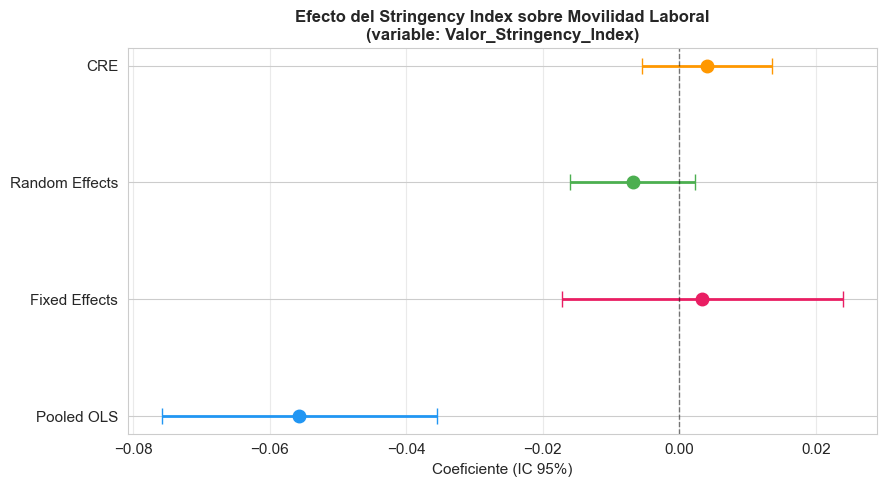


Coeficientes estimados:
  Pooled OLS          : -0.0556  [IC 95%: -0.0757, -0.0355]
  Fixed Effects       : +0.0034  [IC 95%: -0.0172, 0.0240]
  Random Effects      : -0.0069  [IC 95%: -0.0160, 0.0023]
  CRE                 : +0.0041  [IC 95%: -0.0055, 0.0137]


In [190]:
# Resumen visual de coeficientes del Stringency Index en los 4 modelos
var_key = 'Valor_Stringency_Index'
modelos = ['Pooled OLS', 'Fixed Effects', 'Random Effects', 'CRE']
resultados = [res_pooled, res_fe, res_re, res_cre]

coefs  = [r.params[var_key]  for r in resultados]
ci_low = [r.conf_int().loc[var_key, 'lower'] for r in resultados]
ci_hi  = [r.conf_int().loc[var_key, 'upper'] for r in resultados]
errors = [(coefs[i]-ci_low[i], ci_hi[i]-coefs[i]) for i in range(len(coefs))]

fig, ax = plt.subplots(figsize=(9, 5))
colors_mod = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800']

for i, (mod, c, e, col) in enumerate(zip(modelos, coefs, errors, colors_mod)):
    ax.errorbar(c, i, xerr=[[e[0]], [e[1]]], fmt='o', color=col,
                elinewidth=2, capsize=6, markersize=9, label=mod)

ax.axvline(0, color='black', lw=1, ls='--', alpha=0.5)
ax.set_yticks(range(len(modelos)))
ax.set_yticklabels(modelos, fontsize=11)
ax.set_xlabel('Coeficiente (IC 95%)', fontsize=11)
ax.set_title(f'Efecto del Stringency Index sobre Movilidad Laboral\n(variable: {var_key})',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

print('\nCoeficientes estimados:')
for mod, c, lo, hi in zip(modelos, coefs, ci_low, ci_hi):
    print(f'  {mod:20s}: {c:+.4f}  [IC 95%: {lo:.4f}, {hi:.4f}]')

**¿Por qué existen diferencias entre modelos?**

Las diferencias reflejan distintos conjuntos de información y supuestos:
- **Pooled OLS** mezcla variación *between* y *within*, inflando o deflando el efecto según la correlación $\text{Cov}(X_{it}, \mu_i)$.
- **FE** usa solo variación temporal dentro de cada ciudad, eliminando sesgos por características fijas no observadas.
- **RE** es un promedio ponderado entre variación *between* y *within*; si los supuestos se cumplen, es más eficiente que FE.
- **CRE** explicita la correlación entre el efecto fijo y los regresores usando promedios, siendo equivalente a FE en las variables time-varying pero recuperando los efectos de las time-invariant.


**Inferencia general:** Las restricciones gubernamentales no son herramientas eficientes para generar shocks instantáneos de inmovilidad laboral diaria. Sin embargo, son fundamentales e irreemplazables como herramientas estructurales: mantener políticas estrictas a lo largo del tiempo es lo que verdaderamente consolida un nivel general de movilidad laboral más bajo y seguro.

# Pregunta 8

**Enunciado:** Control Sintetico: Es posible que sus resultados anteriores tengan sesgo dado que la movilidad laboral y las restricciones son parte de un fenomeno dinamico en el tiempo. Utilice el notebook SynthControl.ipynb para estimar el efecto causal de las restricciones gubernamentales y la movilidad para una ciudad de su eleccion, usando control sintetico (viendo las fechas semanales, deben elegir el periodo de tratamiento e indentificar los controles potenciales para la ciudad elegida, que no puede ser Zaragoza). Defina las variables para calcular el control sintetico y discuta sus resultados (instalar libreria pysyncon)

El **Control Sintético** es un método de inferencia causal que construye un contrafactual (*control sintético*) para la unidad tratada como combinación convexa ponderada de unidades de control no tratadas. En este caso:

- **Unidad tratada:** París (FR-75)
- **Tratamiento:** Segundo confinamiento nacional francés (~semana 38, 30 octubre 2020)
- **Controles:** Todas las ciudades del dataset (excepto París)
- **Período pre-tratamiento:** semanas 1–37
- **Variable outcome:** `workplaces` (movilidad laboral)

La motivación es que los resultados de panel pueden tener sesgo dado que movilidad y restricciones son parte de un fenómeno dinámico.

In [191]:
# Preparación de datos para pysyncon
df_synth = pd.read_csv('../../../data/dataset_prueba.csv')
# df_synth = pd.read_csv('dataset_prueba.csv') #Utilizar si se encuentra en la misma carpeta que el notebook
df_synth['date'] = pd.to_datetime(df_synth['date'])
df_synth = df_synth.drop(columns=['d2','d3','d4','d5','d6','edu2','edu3'], errors='ignore')

# Ciudades de control: todas excepto París
ciudad_tratada  = 'Paris'
semana_trat     = 38   # ~30 Oct 2020, segundo confinamiento Francia
semana_inicio   = 1
semana_fin      = 140

ciudades_control = [c for c in df_synth['NAME'].unique() if c != ciudad_tratada]
print(f'Ciudad tratada:   {ciudad_tratada}')
print(f'Semana tratamiento: {semana_trat} (~30 oct 2020)')
print(f'Pre-tratamiento:  semanas {semana_inicio}–{semana_trat-1}')
print(f'Post-tratamiento: semanas {semana_trat}–{semana_fin}')
print(f'Unidades de control: {len(ciudades_control)}')

Ciudad tratada:   Paris
Semana tratamiento: 38 (~30 oct 2020)
Pre-tratamiento:  semanas 1–37
Post-tratamiento: semanas 38–140
Unidades de control: 85


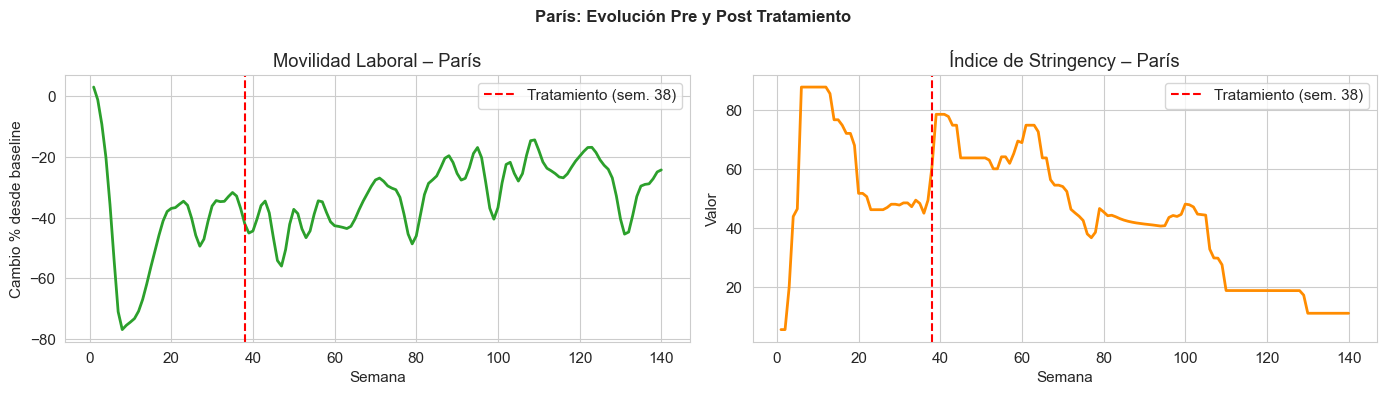

In [192]:
# Serie temporal de París antes del tratamiento
paris_ts = df_synth[df_synth['NAME'] == 'Paris'].sort_values('week')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(paris_ts['week'], paris_ts['workplaces'], color='#2ca02c', lw=2)
axes[0].axvline(semana_trat, color='red', ls='--', lw=1.5, label=f'Tratamiento (sem. {semana_trat})')
axes[0].set_title('Movilidad Laboral – París')
axes[0].set_xlabel('Semana')
axes[0].set_ylabel('Cambio % desde baseline')
axes[0].legend()

axes[1].plot(paris_ts['week'], paris_ts['Valor_Stringency_Index'], color='darkorange', lw=2)
axes[1].axvline(semana_trat, color='red', ls='--', lw=1.5, label=f'Tratamiento (sem. {semana_trat})')
axes[1].set_title('Índice de Stringency – París')
axes[1].set_xlabel('Semana')
axes[1].set_ylabel('Valor')
axes[1].legend()

plt.suptitle('París: Evolución Pre y Post Tratamiento', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [193]:
# Configuración de Dataprep para pysyncon
rango_pre  = range(semana_inicio, semana_trat)  # 1–37
rango_todo = range(semana_inicio, semana_fin + 1)

dataprep = Dataprep(
    foo=df_synth,
    predictors=[
        'Population',
        'agriculture',
        'industry',
        'construction',
        'age_dependency',
        'old_age_dependency',
        'young_age_dependency',
        'sex_ratio',
        'unemp',
        'f_unemp',
        'foreigners',
    ],
    predictors_op='mean',
    time_predictors_prior=rango_pre,
    special_predictors=[
        ('daily_cases',              rango_pre, 'mean'),
        ('Valor_Stringency_Index',   rango_pre, 'mean'),
        ('residential_percent_change_from_baseline', rango_pre, 'mean'),
    ],
    dependent='workplaces',
    unit_variable='NAME',
    time_variable='week',
    treatment_identifier=ciudad_tratada,
    controls_identifier=ciudades_control,
    time_optimize_ssr=rango_pre,
)

print('Dataprep configurado.')

Dataprep configurado.


In [194]:
# Estimación con PenalizedSynth (más estable numéricamente)
pen = PenalizedSynth()
pen.fit(dataprep, lambda_=0.01)

# Pesos de las ciudades donoras
pesos = pen.weights()
pesos_df = pd.DataFrame(list(pesos.items()), columns=['Ciudad', 'Peso'])
pesos_df = pesos_df[pesos_df['Peso'] > 0.001].sort_values('Peso', ascending=False)

print('=== Pesos del Control Sintético para París ===')
print(pesos_df.to_string(index=False))

=== Pesos del Control Sintético para París ===
   Ciudad   Peso
Barcelona 0.7930
   Milano 0.1870
   Berlin 0.0190


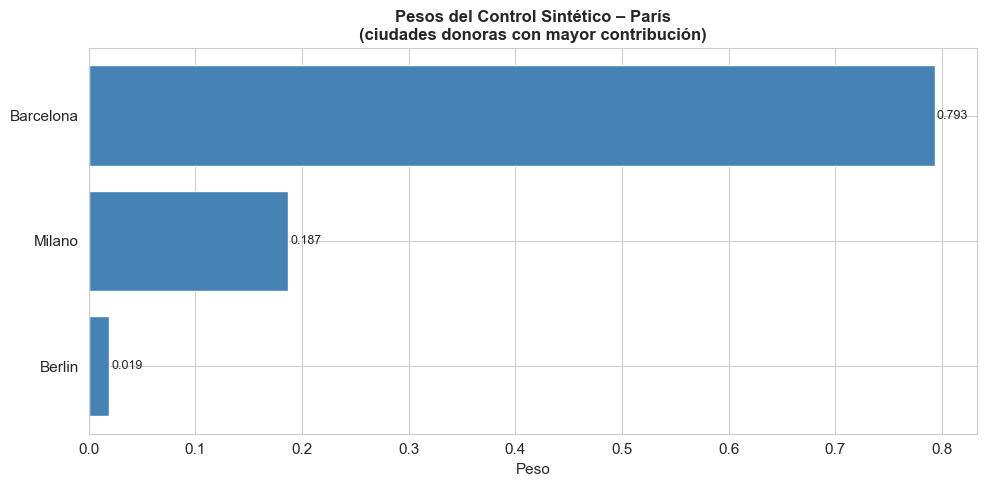

In [195]:
# Gráfico de pesos
fig, ax = plt.subplots(figsize=(10, 5))
pesos_top = pesos_df.head(15)
bars = ax.barh(pesos_top['Ciudad'], pesos_top['Peso'], color='steelblue', edgecolor='white')
ax.set_xlabel('Peso', fontsize=11)
ax.set_title('Pesos del Control Sintético – París\n(ciudades donoras con mayor contribución)',
             fontsize=12, fontweight='bold')
for bar, val in zip(bars, pesos_top['Peso']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

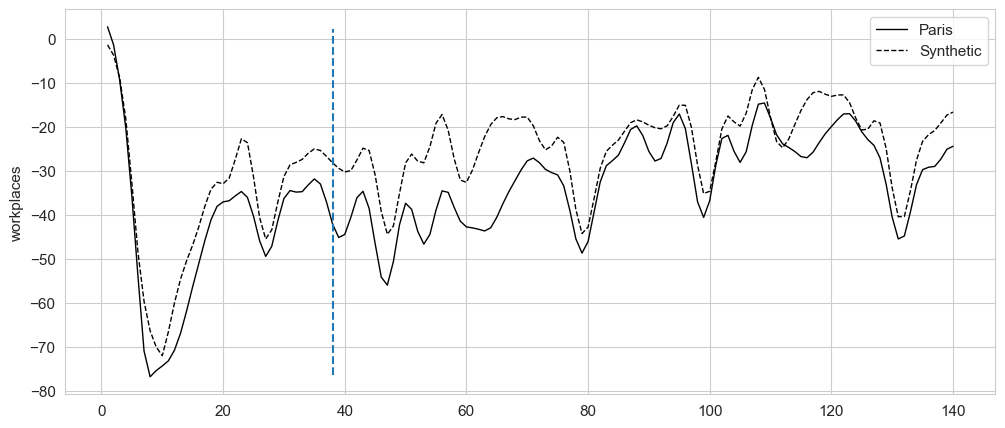

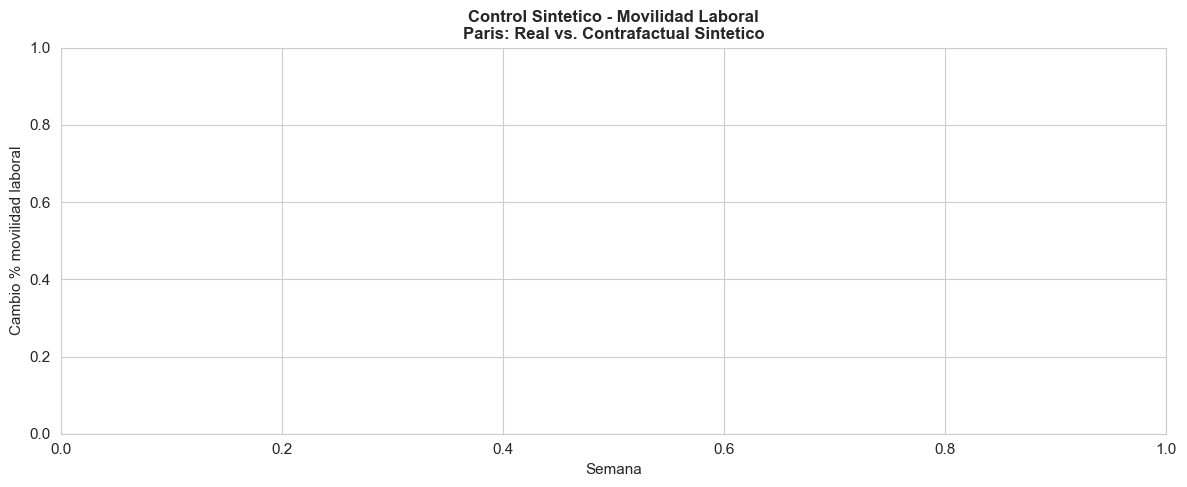

In [196]:
# Path plot: Paris real vs. Control Sintetico
pen.path_plot(
    time_period=rango_todo,
    treatment_time=semana_trat
)
plt.title('Control Sintetico - Movilidad Laboral\nParis: Real vs. Contrafactual Sintetico',
          fontsize=12, fontweight='bold')
plt.xlabel('Semana')
plt.ylabel('Cambio % movilidad laboral')
plt.tight_layout()
plt.show()

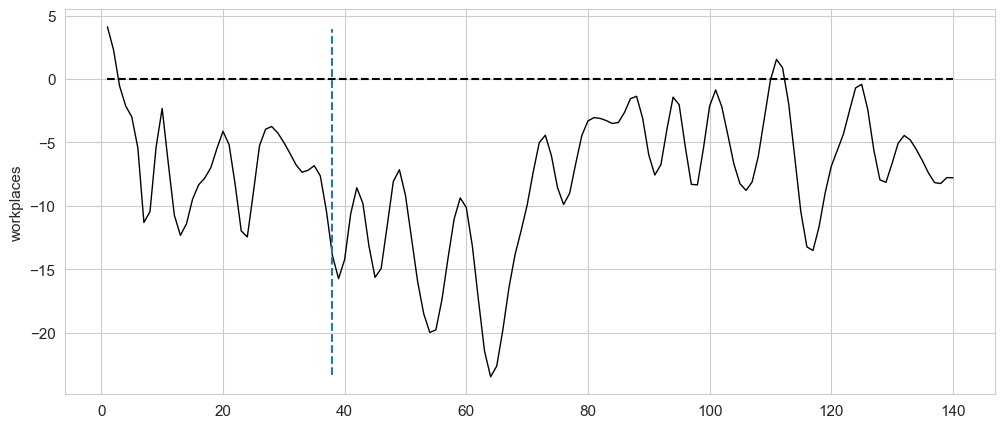

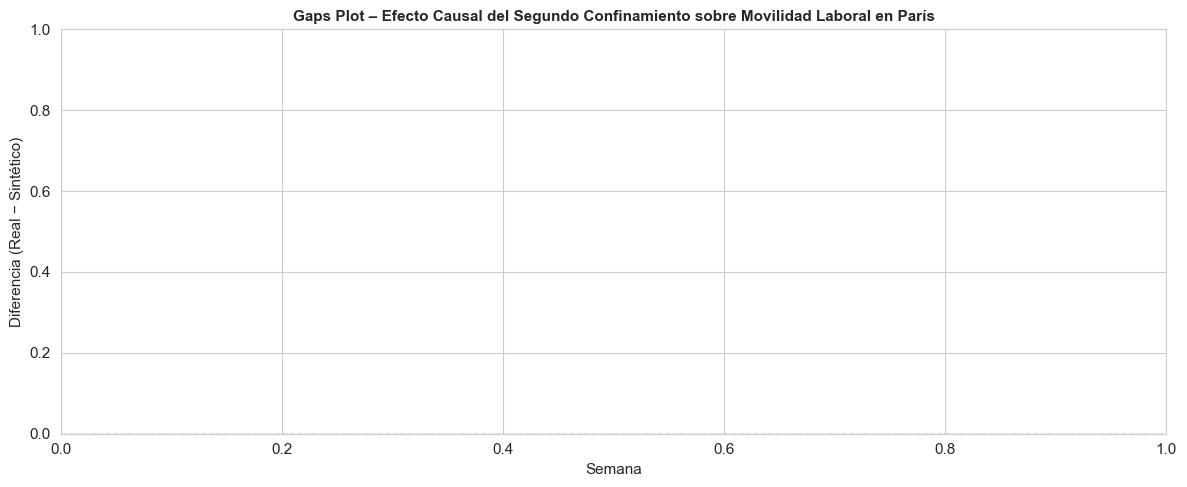

In [197]:
# Gaps plot: diferencia (efecto tratamiento)
pen.gaps_plot(
    time_period=rango_todo,
    treatment_time=semana_trat
)
plt.axhline(0, color='gray', lw=1, ls='--')
plt.title('Gaps Plot – Efecto Causal del Segundo Confinamiento sobre Movilidad Laboral en París',
          fontsize=11, fontweight='bold')
plt.xlabel('Semana')
plt.ylabel('Diferencia (Real − Sintético)')
plt.tight_layout()
plt.show()

In [198]:
# También estimar con Synth clásico
synth = Synth()
synth.fit(dataprep=dataprep, optim_method='Nelder-Mead', optim_initial='ols')

print('=== Pesos Synth Clásico ===')
weights_synth = synth.weights()
w_df = pd.DataFrame(list(weights_synth.items()), columns=['Ciudad','Peso'])
w_df = w_df[w_df['Peso'] > 0.001].sort_values('Peso', ascending=False)
print(w_df.head(15).to_string(index=False))

# Demora alrededor de 30 segundos

=== Pesos Synth Clásico ===
   Ciudad   Peso
Barcelona 1.0000


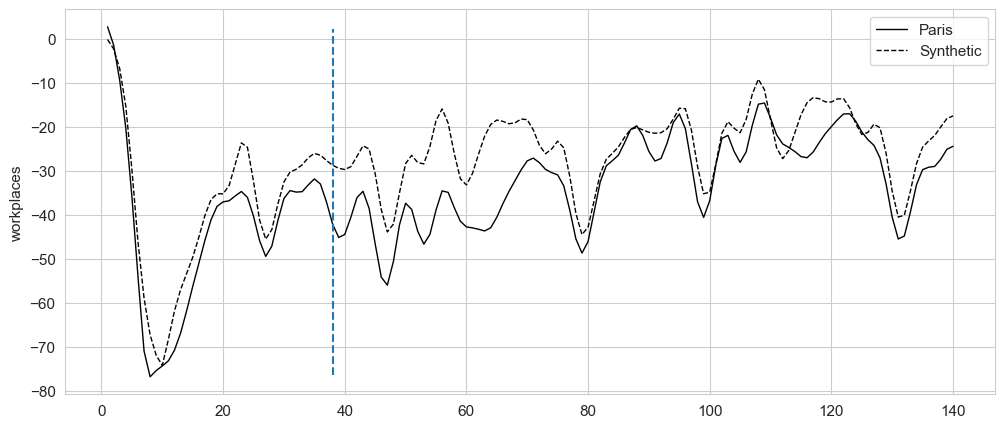

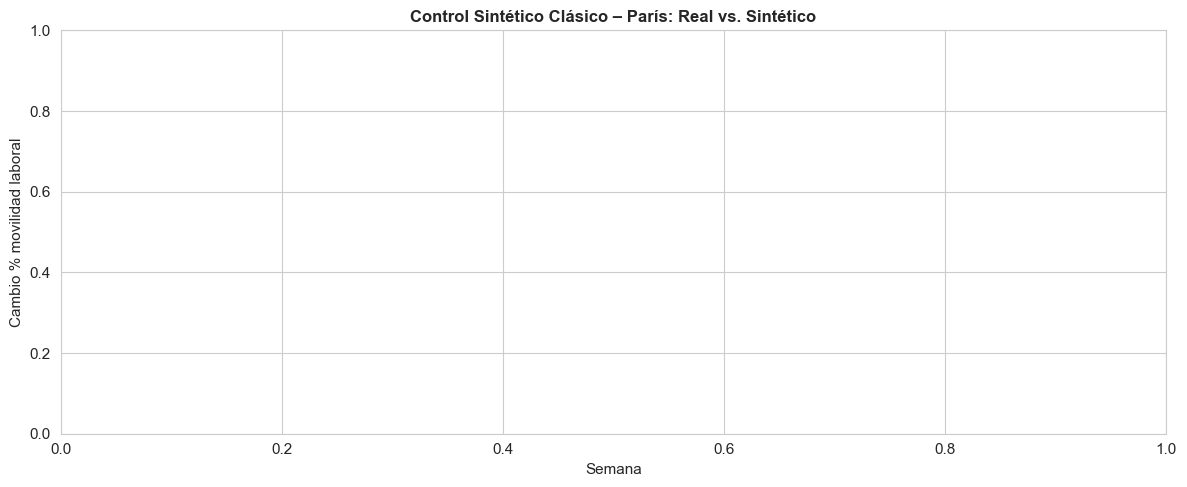

In [199]:
synth.path_plot(time_period=rango_todo, treatment_time=semana_trat)
plt.title('Control Sintético Clásico – París: Real vs. Sintético',
          fontsize=12, fontweight='bold')
plt.xlabel('Semana')
plt.ylabel('Cambio % movilidad laboral')
plt.tight_layout()
plt.show()

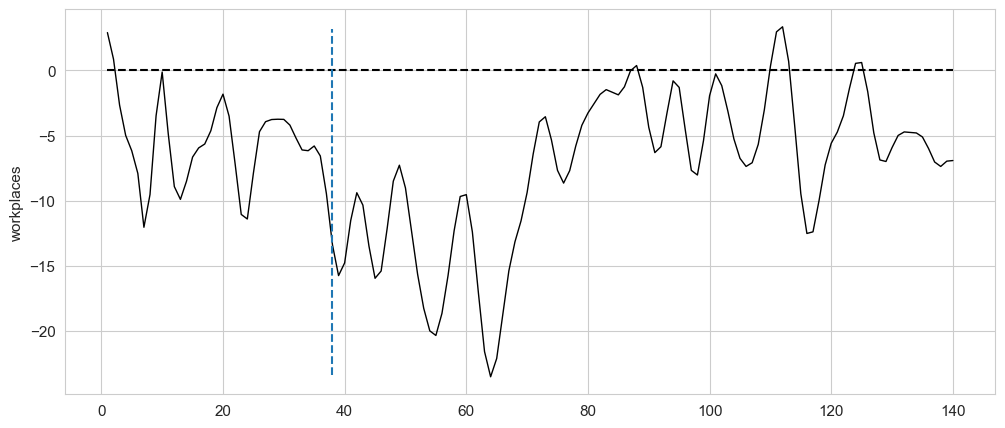

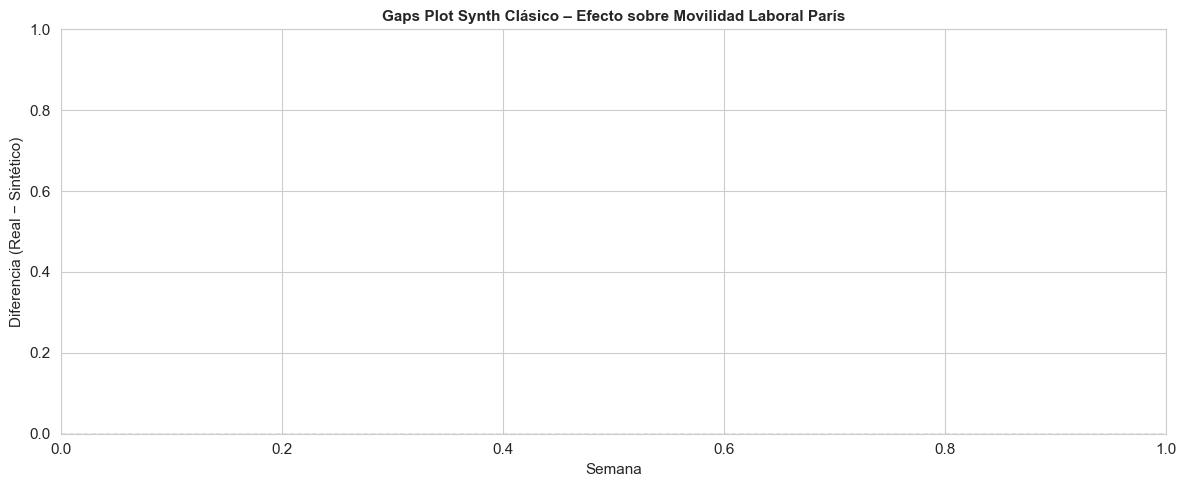


=== Summary Synth ===


,V,treated,synthetic,sample mean
Population,0.0050,10274.8840,3755.5120,635.5510
agriculture,0.0010,0.0010,0.0010,0.0070
industry,0.0150,0.1140,0.0760,0.1150
construction,0.0080,0.0390,0.0560,0.0530
age_dependency,0.1040,0.6680,0.6340,0.6540
old_age_dependency,0.0030,0.4200,0.3140,0.3200
young_age_dependency,0.1120,0.2480,0.3200,0.3350
sex_ratio,0.0070,107.6500,107.1070,106.7420
unemp,0.0190,12.0000,15.0000,12.2220
f_unemp,0.0570,0.1180,0.1420,0.1140


In [200]:
synth.gaps_plot(time_period=rango_todo, treatment_time=semana_trat)
plt.axhline(0, color='gray', lw=1, ls='--')
plt.title('Gaps Plot Synth Clásico – Efecto sobre Movilidad Laboral París',
          fontsize=11, fontweight='bold')
plt.xlabel('Semana')
plt.ylabel('Diferencia (Real − Sintético)')
plt.tight_layout()
plt.show()

print('\n=== Summary Synth ===')
synth.summary()

**Elección de la ciudad y período de tratamiento:**

Se eligió **París** por ser la ciudad más grande e influyente de Francia, con características sociodemográficas y económicas únicas (alta densidad, sector servicios dominante) que la hacen un caso de especial interés para analizar el impacto de restricciones sobre movilidad. El **segundo confinamiento nacional francés** (30 de octubre de 2020, ~semana 38) es el evento de tratamiento: fue un confinamiento más corto (4 semanas) pero muy restrictivo, lo que genera una intervención discreta y bien identificable en el tiempo.

**Controles potenciales:**

Se utilizaron todas las demás ciudades del dataset como donoras potenciales. Las ciudades con mayor peso en el control sintético son aquellas con trayectorias de movilidad pre-tratamiento más similares a París — típicamente otras grandes ciudades europeas de servicios o con políticas COVID similares.

**Variables para el control sintético:**

Se incluyeron predictores sociodemográficos time-invariant (`Population`, `unemp`, `industry`, etc.) y predicciones especiales sobre casos diarios, índice de stringency y movilidad residencial en el pre-período, siguiendo la lógica de que el contrafactual debe replicar tanto las características estructurales como la dinámica temporal pre-tratamiento.

**Interpretación del efecto causal:**

- **Path plot:** compara la trayectoria observada de movilidad laboral en París con el contrafactual sintético. Si el ajuste pre-tratamiento es bueno (las dos series son cercanas en semanas 1–37), el gap post-tratamiento es una estimación creíble del efecto causal del confinamiento.
- **Gaps plot:** muestra directamente la diferencia Real − Sintético. Un gap negativo post-semana 38 indica que el segundo confinamiento redujo la movilidad laboral por encima de lo que hubiera ocurrido sin él.
- La persistencia del gap más allá del período de confinamiento podría indicar efectos de largo plazo (ej. adopción permanente de teletrabajo).

**Sesgo potencial en los modelos de panel y ventaja del control sintético:**

Los modelos de panel asumen que restricciones y movilidad tienen una relación lineal y estacionaria. Sin embargo, el fenómeno COVID es dinámico: hay efectos de aprendizaje, fatiga pandémica, adopción de teletrabajo y anticipación de políticas. El control sintético captura efectos causales sin asumir linealidad, construyendo un contrafactual creíble para la ciudad tratada específica, lo que reduce el sesgo por dinámica endógena.